# Housing Affordability Risk in Australian Cities (2015-2025)

*Author: Roja Joshi*

*Date: March 7, 2026*

---

### Project Overview
This project analyses housing affordability across major Australian cities by examining housing prices, wage growth, and interest rates. 

The goal is to understand how housing affordability has evolved over time and to identify cities that face the highest levels of housing risk.

By combining multiple economic indicators, the analysis evaluates both structural affordability pressures and the impact of monetary policy changes on mortgage stress.

### Key Questions
- Are housing prices diverging from wage growth across Australian cities?
- How has mortgage stress evolved over time?
- What impact did the 2022 RBA interest rate hikes have on affordability?
- Which cities exhibit the highest structural housing risk?

### Key Indicators Constructed
Several affordability indicators are developed for this analysis:

- **Price-to-Income Ratio (PIR)** – long-run affordability measure
- **Wage vs Housing Growth Gap** – divergence between housing and wage growth
- **Mortgage Stress Ratio** – share of income required for mortgage repayments
- **Composite Housing Risk Index** – combined indicator of housing vulnerability

**Note:** The analysis covers quarterly data from 2015 to 2025 for eight Australian capital cities.

---

## Table of Contents
1. [Import Libraries](#1)
2. [Data Sources](#2)
3. [Data Collection](#3)
4. [Data Cleaning & Preparation](#4)
5. [Housing Prices & Income Trends](#5)
6. [Affordability Metric: PIR](#6)
7. [Wage vs Housing Growth Gap](#7)
8. [Mortgage Stress Model](#8)
9. [Composite Housing Risk Index](#9)
10. [Key Findings Summary](#10)
11. [Limitations & Caveats](#11)
12. [Conclusion & Recommendations](#12)

---

## 1. Import Libraries <a id='1'></a>
The following libraries are used for data manipulation, statistical analysis, and visualisation throughout the notebook.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import seaborn as sns

#Visualisation
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

# Outlier detection and standardisation
from scipy.stats import zscore

---

## 2. Data Sources <a id='2'></a>

The analysis combines multiple datasets from official Australian sources:

1. **ABS Residential Property Price Index (RPPI)**  
   Measures changes in residential property prices across Australian capital cities.  
   Source: [Australian Bureau of Statistics – Residential Property Price Index](https://www.abs.gov.au/statistics/economy/price-indexes-and-inflation/residential-property-price-indexes-eight-capital-cities)

2. **ABS Average Weekly Earnings (AWE)**  
   Used to estimate annual household income for affordability calculations.  
   Source: [Australian Bureau of Statistics – Average Weekly Earnings](https://www.abs.gov.au/statistics/labour/earnings-and-working-conditions/average-weekly-earnings-australia)

3. **ABS Wage Price Index (WPI)**  
   Tracks wage growth trends over time.  
   Source: [Australian Bureau of Statistics – Wage Price Index](https://www.abs.gov.au/statistics/economy/price-indexes-and-inflation/wage-price-index-australia)

4. **Median Housing Price Data (PropTrack)**  
   Provides housing price levels used to estimate median property prices.  
   Source: [PropTrack Home Price Index](https://www.proptrack.com.au/home-price-index/)

5. **RBA Cash Rate Data**  
   Represents monetary policy conditions affecting mortgage borrowing costs.  
   Source: [Reserve Bank of Australia – Cash Rate Statistics](https://www.rba.gov.au/statistics/cash-rate/)

---

## 3. Data Collection <a id='3'></a>

In [2]:
# Load raw data
rppi_raw = pd.read_csv("data/abs_rppi_2003_2021.csv")
proptrack_raw = pd.read_csv("data/proptrack_2022_2025.csv")
awe_raw = pd.read_csv("data/AWE_by_state.csv")
cash_raw = pd.read_csv("data/cash_rate.csv")
wpi_raw = pd.read_csv("data/WPI_by_state.csv")

---

## 4. Data Cleaning & Preparation <a id='4'></a>

### 4.1 Data Inspection
Before cleaning the datasets, the structure and contents of each dataset are inspected.  
This step helps identify metadata rows, missing values, and formatting issues that must be addressed during the cleaning process.

#### ABS RPPI data

In [3]:
# Inspect shape
print("RPPI:", rppi_raw.shape)

RPPI: (83, 28)


In [4]:
# Preview first 10 rows
rppi_raw.head(10)

,Unnamed: 0,Residential Property Price Index ; Sydney ;,Residential Property Price Index ; Melbourne ;,Residential Property Price Index ; Brisbane ;,Residential Property Price Index ; Adelaide ;,Residential Property Price Index ; Perth ;,Residential Property Price Index ; Hobart ;,Residential Property Price Index ; Darwin ;,Residential Property Price Index ; Canberra ;,Residential Property Price Index ; Weighted average of eight capital cities ;,...,Residential Property Price Index percentage change from corresponding quarter of previous year ; Weighted average of eight capital cities ;,Residential Property Price Index percentage change from previous quarter ; Sydney ;,Residential Property Price Index percentage change from previous quarter ; Melbourne ;,Residential Property Price Index percentage change from previous quarter ; Brisbane ;,Residential Property Price Index percentage change from previous quarter ; Adelaide ;,Residential Property Price Index percentage change from previous quarter ; Perth ;,Residential Property Price Index percentage change from previous quarter ; Hobart ;,Residential Property Price Index percentage change from previous quarter ; Darwin ;,Residential Property Price Index percentage change from previous quarter ; Canberra ;,Residential Property Price Index percentage change from previous quarter ; Weighted average of eight capital cities ;
0,Unit,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,...,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent
1,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,...,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
2,Data Type,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,...,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT
3,Frequency,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,...,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter
4,Collection Month,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
5,Series Start,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,...,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003,Sep-2003
6,Series End,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,...,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021,Dec-2021
7,No. Obs,74,74,74,74,74,74,74,74,74,...,74,74,74,74,74,74,74,74,74,74
8,Series ID,A83728383L,A83728392R,A83728401F,A83728410J,A83728419C,A83728428F,A83728437J,A83728446K,A83728455L,...,A83728461J,A83728386V,A83728395W,A83728404L,A83728413R,A83728422T,A83728431V,A83728440W,A83728449T,A83728458V
9,Sep-2003,85.3,60.7,64.2,62.2,48.3,61.2,40.5,68.3,69.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Dataset summary
rppi_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 28 columns):
 #   Column                                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                                        --------------  ----- 
 0   Unnamed: 0                                                                                                                                    83 non-null     object
 1   Residential Property Price Index ;  Sydney ;                                                                                                  83 non-null     object
 2   Residential Property Price Index ;  Melbourne ;                                                                                               83 non-null     object
 3   Residential Property Price Index ;  Brisba

#### Proptrack Median Housing Price data

In [6]:
# Inspect shape
print("PropTrack:", proptrack_raw.shape)

PropTrack: (248, 6)


In [7]:
# Preview first 10 rows
proptrack_raw.head(10)

,Date,City,Monthly_Growth,Annual_Growth,Median_Value,Note
0,Mar-22,Sydney,32.00%,16.27%,"$982,000.0",NaN
1,Mar-22,Melbourne,-0.02%,10.40%,"$780,000.0",NaN
2,Mar-22,Adelaide,0.84%,24.90%,"$548,000.0",NaN
3,Mar-22,Brisbane,0.49%,27.02%,"$627,000.0",NaN
4,Mar-22,Perth,-0.11%,7.67%,"$520,000.0",NaN
5,Mar-22,Hobart,0.19%,23.85%,"$657,000.0",NaN
6,Mar-22,Canberra (ACT),0.35%,26.40%,"$813,000.0",NaN
7,Mar-22,Darwin,-0.61%,9.47%,"$479,000.0",NaN
8,Jun-22,Sydney,-0.40%,6.41%,"$1,015,000.0",NaN
9,Jun-22,Melbourne,-0.61%,5.00%,"$796,000.0",NaN


In [8]:
# Dataset summary
proptrack_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            128 non-null    object
 1   City            128 non-null    object
 2   Monthly_Growth  128 non-null    object
 3   Annual_Growth   128 non-null    object
 4   Median_Value    128 non-null    object
 5   Note            30 non-null     object
dtypes: object(6)
memory usage: 11.8+ KB


#### AWE data

In [9]:
# Inspect shape
print("AWE:", awe_raw.shape)

AWE: (34, 9)


In [10]:
# Preview first 10 rows
awe_raw.head(10)

,Date,NSW,VC,QLD,SA,WA,TAS,NT,ACT
0,May-15,1512.10,1396.60,1440.90,1348.20,1691.20,1289.00,1513.50,1707
1,Nov-15,1527.30,1424.80,1446.70,1376.00,1708.70,1318.70,1553.00,1715.6
2,May-16,1541.00,1454.50,1460.30,1414.90,1698.60,1334.70,1569.70,1725.4
3,Nov-16,1535.80,1500.10,1482.10,1446.00,1703.20,1345.10,1638.50,1747
4,May-17,1545.80,1507.70,1496.10,1447.60,1714.70,1352.80,1616.50,1774.1
5,Nov-17,1585.90,1524.30,1527.80,1441.50,1742.80,1356.20,1647.90,1803.1
6,May-18,1606.10,1545.30,1541.90,1448.60,1740.30,1379.30,1668.50,1810.1
7,Nov-18,1622.10,1568.80,1574.00,1462.20,1757.10,1399.50,1643.30,1813.3
8,May-19,1664.1,1608.3,1577.2,1475.1,1780.8,1420.5,1690.3,1809.7
9,Nov-19,1680,1647,1609,1504,1778,1450,1685,1830


In [11]:
# Dataset summary
awe_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    22 non-null     object
 1   NSW     22 non-null     object
 2   VC      22 non-null     object
 3   QLD     22 non-null     object
 4   SA      22 non-null     object
 5   WA      22 non-null     object
 6   TAS     22 non-null     object
 7   NT      22 non-null     object
 8   ACT     22 non-null     object
dtypes: object(9)
memory usage: 2.5+ KB


#### Cash Rate data

In [12]:
# Inspect shape
print("Cash:", cash_raw.shape)

Cash: (3845, 19)


In [13]:
# Preview first 10 rows
cash_raw.head(10)

,F1 INTEREST RATES AND YIELDS – MONEY MARKET,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,Title,Cash Rate Target,Change in the Cash Rate Target,Interbank Overnight Cash Rate,Highest Interbank Overnight Cash Rate,Lowest Interbank Overnight Cash Rate,Volume of Cash Market Transactions,Number of Cash Market Transactions,Total Return Index,EOD 1-month BABs/NCDs,EOD 3-month BABs/NCDs,EOD 6-month BABs/NCDs,1-month OIS,3-month OIS,6-month OIS,1-month Treasury Note,3- month Treasury Note,6- month Treasury Note,NaN
1,Description,Cash Rate Target on date,Change in the Cash Rate Target (in percentage ...,Interbank Overnight Cash Rate on date,Highest Interbank Overnight Cash Rate on date,Lowest Interbank Overnight Cash Rate on date,Volume of Interbank Overnight Cash Market Tran...,Number of Interbank Overnight Cash Market Tran...,Cash Rate Total Return Index on date,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Overnight Indexed Swaps-1 month,Overnight Indexed Swaps-3 months,Overnight Indexed Swaps-6 months,Treasury Note-1 month,Treasury Note-3 month,Treasury Note-6 month,NaN
2,Frequency,Daily,as announced,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,NaN
3,Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,NaN
4,Units,Per cent,Per cent,Per cent,Per cent,Per cent,$m,Number,Index 04-Jan-2011=100,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Source,RBA,RBA,RBA,RBA,RBA,RBA,RBA,RBA,ASX,ASX,ASX,FENICS,FENICS,FENICS,RBA,RBA,RBA,NaN
8,Publication date,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,NaN
9,Series ID,FIRMMCRTD,FIRMMCCRT,FIRMMCRID,FIRMMCRIH,FIRMMCRIL,FIRMMCRIV,FIRMMCRIN,FIRMMCTRI,FIRMMBAB30D,FIRMMBAB90D,FIRMMBAB180D,FIRMMOIS1D,FIRMMOIS3D,FIRMMOIS6D,FIRMMTN1D,FIRMMTN3D,FIRMMTN6D,NaN


In [14]:
# Dataset summary
cash_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3845 entries, 0 to 3844
Data columns (total 19 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   F1 INTEREST RATES AND YIELDS – MONEY MARKET  3843 non-null   object 
 1   Unnamed: 1                                   3842 non-null   object 
 2   Unnamed: 2                                   43 non-null     object 
 3   Unnamed: 3                                   3842 non-null   object 
 4   Unnamed: 4                                   2946 non-null   object 
 5   Unnamed: 5                                   2946 non-null   object 
 6   Unnamed: 6                                   3243 non-null   object 
 7   Unnamed: 7                                   2194 non-null   object 
 8   Unnamed: 8                                   3843 non-null   object 
 9   Unnamed: 9                                   3813 non-null   object 
 10  

#### WPI data

In [15]:
# Inspect shape
print("WPI:", wpi_raw.shape)

WPI: (123, 28)


In [16]:
# Preview first 10 rows
wpi_raw.head(10)

,Unnamed: 0,Quarterly Index ; Total hourly rates of pay excluding bonuses ; New South Wales ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Victoria ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Queensland ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; South Australia ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Western Australia ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Tasmania ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Northern Territory ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Australian Capital Territory ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Australia ; Private and Public ; All industries ;,...,Percentage Change from Previous Quarter ; Total hourly rates of pay excluding bonuses ; Australia ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; New South Wales ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Victoria ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Queensland ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; South Australia ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Western Australia ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Tasmania ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Northern Territory ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Australian Capital Territory ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Australia ; Private and Public ; All industries ;
0,Unit,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,...,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent
1,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,...,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
2,Data Type,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,...,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT
3,Frequency,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,...,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter
4,Collection Month,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
5,Series Start,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,...,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997
6,Series End,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,...,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025
7,No. Obs,114,114,114,114,114,114,114,114,114,...,114,114,114,114,114,114,114,114,114,114
8,Series ID,A2599619A,A2608929K,A

In [17]:
# Dataset summary
wpi_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 28 columns):
 #   Column                                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                                  --------------  ----- 
 0   Unnamed: 0                                                                                                                                                                              123 non-null    object
 1   Quarterly Index ;  Total hourly rates of pay excluding bonuses ;  New South Wales ;  Private and Public ;  All industries ;                                                             123 non-null    object
 2   Quarterly Index ;  Total hourly rates of p

### 4.2 Data Cleaning

Each dataset required cleaning due to different formats and metadata rows. Data were converted to datatime format and unnecessary columns were removed.

#### ABS RPPI data
The RPPI dataset from the Australian Bureau of Statistics contains quarterly residential property price indices for Australian capital cities. However, it includes metadata rows and non-standard column names that must be cleaned before analysis. 
The following steps prepare the data for integration with other datasets.

In [18]:
# Load RPPI dataset skipping metadata rows
rppi = pd.read_csv("data/abs_rppi_2003_2021.csv", skiprows=9)

In [19]:
rppi.head()

,Series ID,A83728383L,A83728392R,A83728401F,A83728410J,A83728419C,A83728428F,A83728437J,A83728446K,A83728455L,...,A83728461J,A83728386V,A83728395W,A83728404L,A83728413R,A83728422T,A83728431V,A83728440W,A83728449T,A83728458V
0,Sep-2003,85.3,60.7,64.2,62.2,48.3,61.2,40.5,68.3,69.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dec-2003,88.2,62.1,69.4,63.9,50.6,66.5,43.3,70.9,71.6,...,NaN,3.4,2.3,8.1,2.7,4.8,8.7,6.9,3.8,3.8
2,Mar-2004,87.0,60.8,70.7,64.8,52.5,68.7,45.5,69.9,71.3,...,NaN,-1.4,-2.1,1.9,1.4,3.8,3.3,5.1,-1.4,-0.4
3,Jun-2004,84.4,60.9,71.7,65.9,53.7,71.8,45.2,70.1,70.6,...,NaN,-3.0,0.2,1.4,1.7,2.3,4.5,-0.7,0.3,-1.0
4,Sep-2004,84.2,60.9,71.2,67.1,54.7,72.3,46.8,68.6,70.6,...,2.3,-0.2,0.0,-0.7,1.8,1.9,0.7,3.5,-2.1,0.0


In [20]:
print(rppi.columns)

Index(['Series ID', 'A83728383L', 'A83728392R', 'A83728401F', 'A83728410J',
       'A83728419C', 'A83728428F', 'A83728437J', 'A83728446K', 'A83728455L',
       'A83728389A', 'A83728398C', 'A83728407V', 'A83728416W', 'A83728425X',
       'A83728434A', 'A83728443C', 'A83728452F', 'A83728461J', 'A83728386V',
       'A83728395W', 'A83728404L', 'A83728413R', 'A83728422T', 'A83728431V',
       'A83728440W', 'A83728449T', 'A83728458V'],
      dtype='object')


In [21]:
# Rename first column to 'Date' for clarity
rppi = rppi.rename(columns={rppi.columns[0]: "Date"})

In [22]:
rppi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        74 non-null     object 
 1   A83728383L  74 non-null     float64
 2   A83728392R  74 non-null     float64
 3   A83728401F  74 non-null     float64
 4   A83728410J  74 non-null     float64
 5   A83728419C  74 non-null     float64
 6   A83728428F  74 non-null     float64
 7   A83728437J  74 non-null     float64
 8   A83728446K  74 non-null     float64
 9   A83728455L  74 non-null     float64
 10  A83728389A  70 non-null     float64
 11  A83728398C  70 non-null     float64
 12  A83728407V  70 non-null     float64
 13  A83728416W  70 non-null     float64
 14  A83728425X  70 non-null     float64
 15  A83728434A  70 non-null     float64
 16  A83728443C  70 non-null     float64
 17  A83728452F  70 non-null     float64
 18  A83728461J  70 non-null     float64
 19  A83728386V  73 non-null     flo

In [23]:
# Select only the relevant columns
rppi = rppi.iloc[:, :9]  # Date + first 8 cities

In [24]:
# Rename city columns
rppi.columns = [
    "Date",
    "Sydney",
    "Melbourne",
    "Brisbane",
    "Adelaide",
    "Perth",
    "Hobart",
    "Darwin",
    "Canberra"
]

In [25]:
# Convert 'Date' column from object to datetime type
rppi["Date"] = pd.to_datetime(rppi["Date"])

C:\Users\rojaj\AppData\Local\Temp\ipykernel_59584\3990881902.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rppi["Date"] = pd.to_datetime(rppi["Date"])


In [26]:
# Filter analysis period (2015-2025)
rppi = rppi[
    (rppi["Date"] >= "2015-01-01") &
    (rppi["Date"] <= "2021-12-31")
]

#### Proptrack Median Housing Price data

In [27]:
# Inspect date format
proptrack_raw["Date"].unique()[:20]

array(['Mar-22', 'Jun-22', 'Sep-22', 'Dec-22', 'Mar-23', 'Jun-23',
       'Sep-23', 'Dec-23', 'Mar-24', 'Jun-24', 'Sep-24', 'Dec-24',
       'Mar-25', 'Jun-25', 'Sep-25', 'Dec-25', nan], dtype=object)

In [28]:
# Copy dataset to preserve the raw dataset
proptrack = proptrack_raw.copy()

# Convert 'Date' column from object to datetime type
proptrack["Date"] = pd.to_datetime(
    proptrack["Date"],
    format="%b-%y",
    errors="coerce"
)

In [29]:
# Clean median housing price values
proptrack["Median_Value"] = (
    proptrack["Median_Value"]
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

In [30]:
proptrack.head(10)

,Date,City,Monthly_Growth,Annual_Growth,Median_Value,Note
0,2022-03-01,Sydney,32.00%,16.27%,982000.0,NaN
1,2022-03-01,Melbourne,-0.02%,10.40%,780000.0,NaN
2,2022-03-01,Adelaide,0.84%,24.90%,548000.0,NaN
3,2022-03-01,Brisbane,0.49%,27.02%,627000.0,NaN
4,2022-03-01,Perth,-0.11%,7.67%,520000.0,NaN
5,2022-03-01,Hobart,0.19%,23.85%,657000.0,NaN
6,2022-03-01,Canberra (ACT),0.35%,26.40%,813000.0,NaN
7,2022-03-01,Darwin,-0.61%,9.47%,479000.0,NaN
8,2022-06-01,Sydney,-0.40%,6.41%,1015000.0,NaN
9,2022-06-01,Melbourne,-0.61%,5.00%,796000.0,NaN


In [31]:
# Standardise city names
proptrack["City"] = proptrack["City"].replace({
    "Canberra (ACT)": "Canberra"
})

#### ABS Average Weekly Earnings (AWE) data
The ABS Average Weekly Earnings dataset provides estimates of average weekly earnings for each Australian state and territory.

Since housing affordability is measured using annual income, weekly earnings are converted to annual income values. The dataset is also reshaped and aligned with quarterly timestamps to match the other datasets used in the analysis.

In [32]:
awe_raw.head()

,Date,NSW,VC,QLD,SA,WA,TAS,NT,ACT
0,May-15,1512.10,1396.60,1440.90,1348.20,1691.20,1289.00,1513.50,1707
1,Nov-15,1527.30,1424.80,1446.70,1376.00,1708.70,1318.70,1553.00,1715.6
2,May-16,1541.00,1454.50,1460.30,1414.90,1698.60,1334.70,1569.70,1725.4
3,Nov-16,1535.80,1500.10,1482.10,1446.00,1703.20,1345.10,1638.50,1747
4,May-17,1545.80,1507.70,1496.10,1447.60,1714.70,1352.80,1616.50,1774.1


In [33]:
# Copy dataset to preserve the raw dataset
awe=awe_raw.copy()

In [34]:
# Convert Date column to datetime type
awe["Date"] = pd.to_datetime(awe["Date"], format="%b-%y")

In [35]:
awe.dtypes

Date    datetime64[ns]
NSW             object
VC              object
QLD             object
SA              object
WA              object
TAS             object
NT              object
ACT             object
dtype: object

In [36]:
state_cols = ["NSW","VC","QLD","SA","WA","TAS","NT","ACT"]

# Convert earnings value to numeric
awe[state_cols] = awe[state_cols].apply(pd.to_numeric, errors="coerce")

**Convert weekly earnings to annual income**

Average weekly earnings are multiplied by 52 to estimate annual income values.  
These annual income estimates are used to compute housing affordability metrics such as the Price-to-Income Ratio.

In [37]:
# Convert Weekly Earnings to Annual Income
awe[state_cols] = awe[state_cols] * 52

The AWE dataset reports average weekly earnings per employee. 
For simplicity, these values are converted to annual income and used as a proxy for household income when calculating housing affordability metrics.

#### RBA Cash Rate data
The Reserve Bank of Australia (RBA) cash rate represents the benchmark interest rate in the Australian economy.

Since mortgage borrowing costs are closely linked to interest rates, the cash rate is used as a proxy for borrowing conditions when estimating mortgage stress.

The dataset is reported daily and must therefore be aggregated to quarterly frequency to align with the other datasets used in the analysis.

In [38]:
# Inspect raw data
cash_raw.head(15)

,F1 INTEREST RATES AND YIELDS – MONEY MARKET,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,Title,Cash Rate Target,Change in the Cash Rate Target,Interbank Overnight Cash Rate,Highest Interbank Overnight Cash Rate,Lowest Interbank Overnight Cash Rate,Volume of Cash Market Transactions,Number of Cash Market Transactions,Total Return Index,EOD 1-month BABs/NCDs,EOD 3-month BABs/NCDs,EOD 6-month BABs/NCDs,1-month OIS,3-month OIS,6-month OIS,1-month Treasury Note,3- month Treasury Note,6- month Treasury Note,NaN
1,Description,Cash Rate Target on date,Change in the Cash Rate Target (in percentage ...,Interbank Overnight Cash Rate on date,Highest Interbank Overnight Cash Rate on date,Lowest Interbank Overnight Cash Rate on date,Volume of Interbank Overnight Cash Market Tran...,Number of Interbank Overnight Cash Market Tran...,Cash Rate Total Return Index on date,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Overnight Indexed Swaps-1 month,Overnight Indexed Swaps-3 months,Overnight Indexed Swaps-6 months,Treasury Note-1 month,Treasury Note-3 month,Treasury Note-6 month,NaN
2,Frequency,Daily,as announced,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,Daily,NaN
3,Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,NaN
4,Units,Per cent,Per cent,Per cent,Per cent,Per cent,$m,Number,Index 04-Jan-2011=100,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Source,RBA,RBA,RBA,RBA,RBA,RBA,RBA,RBA,ASX,ASX,ASX,FENICS,FENICS,FENICS,RBA,RBA,RBA,NaN
8,Publication date,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,27-Feb-2026,NaN
9,Series ID,FIRMMCRTD,FIRMMCCRT,FIRMMCRID,FIRMMCRIH,FIRMMCRIL,FIRMMCRIV,FIRMMCRIN,FIRMMCTRI,FIRMMBAB30D,FIRMMBAB90D,FIRMMBAB180D,FIRMMOIS1D,FIRMMOIS3D,FIRMMOIS6D,FIRMMTN1D,FIRMMTN3D,FIRMMTN6D,NaN


In [39]:
# SKip rows 1 to 9 (metadata) since real data start at row 10
cash = pd.read_csv("data/cash_rate.csv", skiprows=9)

In [40]:
# Rename columns 
cash.rename(columns={
    cash.columns[0]: "Date",
    cash.columns[1]: "Cash_Rate"
}, inplace=True)

In [41]:
# Select relevant variables
cash = cash[["Date", "Cash_Rate"]].copy()

In [42]:
# Convert Date column
cash["Date"] = pd.to_datetime(cash["Date"], errors="coerce")
cash = cash.dropna(subset=["Date"])

C:\Users\rojaj\AppData\Local\Temp\ipykernel_59584\4213169832.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cash["Date"] = pd.to_datetime(cash["Date"], errors="coerce")


In [43]:
# Ensure cash rate is numeric
cash["Cash_Rate"] = pd.to_numeric(cash["Cash_Rate"], errors="coerce")
cash = cash.dropna(subset=["Cash_Rate"])

In [44]:
# Convert percentage values to decimal form
cash['Cash_Rate'] = cash['Cash_Rate'] / 100 

In [45]:
# Filter analysis period (2015-2025)
cash = cash[
    (cash["Date"] >= "2015-01-01") &
    (cash["Date"] <= "2025-12-31")
]

In [46]:
cash.head()

,Date,Cash_Rate
1012,2015-01-02,0.025
1013,2015-01-05,0.025
1014,2015-01-06,0.025
1015,2015-01-07,0.025
1016,2015-01-08,0.025


#### WPI data
The Wage Price Index (WPI) measures changes in wage and salary levels across Australia. 
Unlike AWE, which measures income levels, WPI measures **wage growth over time**.

In this analysis, the WPI is used to evaluate whether housing prices are growing faster than wages, 
which helps identify periods of declining affordability.

In [47]:
wpi_raw.head(10)

,Unnamed: 0,Quarterly Index ; Total hourly rates of pay excluding bonuses ; New South Wales ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Victoria ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Queensland ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; South Australia ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Western Australia ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Tasmania ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Northern Territory ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Australian Capital Territory ; Private and Public ; All industries ;,Quarterly Index ; Total hourly rates of pay excluding bonuses ; Australia ; Private and Public ; All industries ;,...,Percentage Change from Previous Quarter ; Total hourly rates of pay excluding bonuses ; Australia ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; New South Wales ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Victoria ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Queensland ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; South Australia ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Western Australia ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Tasmania ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Northern Territory ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Australian Capital Territory ; Private and Public ; All industries ;,Percentage Change from Corresponding Quarter of Previous Year ; Total hourly rates of pay excluding bonuses ; Australia ; Private and Public ; All industries ;
0,Unit,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,Index Numbers,...,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent,Percent
1,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,...,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
2,Data Type,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,INDEX,...,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT,PERCENT
3,Frequency,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,...,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter
4,Collection Month,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
5,Series Start,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,...,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997,Sep-1997
6,Series End,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,...,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025,Dec-2025
7,No. Obs,114,114,114,114,114,114,114,114,114,...,114,114,114,114,114,114,114,114,114,114
8,Series ID,A2599619A,A2608929K,A

In [48]:
# SKip rows 1 to 9 (metadata) since real data start at row 10
wpi = pd.read_csv("data/WPI_by_state.csv", skiprows=9)

In [49]:
wpi.head()

,Series ID,A2599619A,A2608929K,A2600949X,A2610259A,A2607599L,A2602279K,A2606269C,A2604939T,A2603609J,...,A2603610T,A2599621L,A2608931W,A2600951K,A2610261L,A2607601L,A2602281W,A2606271R,A2604941C,A2603611V
0,Sep-1997,66.8,67.5,66.6,66.9,64.3,67.9,68.0,66.8,66.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dec-1997,67.2,68.0,67.2,67.4,64.9,68.2,68.8,66.9,67.3,...,0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mar-1998,67.9,68.6,67.7,67.8,65.6,68.7,69.2,67.5,67.8,...,0.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jun-1998,68.2,68.9,68.0,68.1,66.0,68.9,69.5,67.8,68.2,...,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sep-1998,69.2,69.7,68.8,69.0,66.5,69.6,70.1,68.7,68.9,...,1.0,3.6,3.3,3.3,3.1,3.4,2.5,3.1,2.8,3.3


In [50]:
# Rename first column as 'Date'
wpi = wpi.rename(columns={wpi.columns[0]: "Date"})

In [51]:
# Convert 'Date' column to datetime
wpi["Date"] = pd.to_datetime(wpi["Date"])

C:\Users\rojaj\AppData\Local\Temp\ipykernel_59584\3771365168.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wpi["Date"] = pd.to_datetime(wpi["Date"])


In [52]:
wpi.head()

,Date,A2599619A,A2608929K,A2600949X,A2610259A,A2607599L,A2602279K,A2606269C,A2604939T,A2603609J,...,A2603610T,A2599621L,A2608931W,A2600951K,A2610261L,A2607601L,A2602281W,A2606271R,A2604941C,A2603611V
0,1997-09-01,66.8,67.5,66.6,66.9,64.3,67.9,68.0,66.8,66.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1997-12-01,67.2,68.0,67.2,67.4,64.9,68.2,68.8,66.9,67.3,...,0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-03-01,67.9,68.6,67.7,67.8,65.6,68.7,69.2,67.5,67.8,...,0.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-06-01,68.2,68.9,68.0,68.1,66.0,68.9,69.5,67.8,68.2,...,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-09-01,69.2,69.7,68.8,69.0,66.5,69.6,70.1,68.7,68.9,...,1.0,3.6,3.3,3.3,3.1,3.4,2.5,3.1,2.8,3.3


In [53]:
# Select only relevant columns
wpi = wpi.iloc[:, :9]  # Date + first 8 cities

In [54]:
# Rename columns
wpi.columns = [
    "Date",
    "NSW",
    "VIC",
    "QLD",
    "SA",
    "WA",
    "TAS",
    "NT",
    "ACT"
]

In [55]:
# Filter analysis period (2015-2025)
wpi = wpi[
    (wpi["Date"] >= "2015-01-01") &
    (wpi["Date"] <= "2026-01-01")
]

### 4.3 Data Preparation

#### Reshape data

In [56]:
# Reshape dataset to long format
rppi_long = rppi.melt(
    id_vars="Date",
    var_name="City",
    value_name="RPPI_Index"
)

In [57]:
# Convert Wide to Long format
awe_long = awe.melt(
    id_vars="Date",
    var_name="State",
    value_name="Annual_Income"
)

In [58]:
# Reshape dataset from wide format to long format
wpi_long = wpi.melt(
    id_vars="Date",
    var_name="State",
    value_name="WPI_Index"
)

#### Map states to cities

In [59]:
# Map each State to the Cities
state_city_map = {
    "NSW": "Sydney",
    "VC": "Melbourne",
    "QLD": "Brisbane",
    "SA": "Adelaide",
    "WA": "Perth",
    "TAS": "Hobart",
    "NT": "Darwin",
    "ACT": "Canberra"
}

In [60]:
awe_long["City"] = awe_long["State"].map(state_city_map)

In [61]:
# Select final columns
awe_long = awe_long[["Date","City","Annual_Income"]]

In [62]:
# Map the states to the capital cities
state_city_map = {
    "NSW": "Sydney",
    "VIC": "Melbourne",
    "QLD": "Brisbane",
    "SA": "Adelaide",
    "WA": "Perth",
    "TAS": "Hobart",
    "NT": "Darwin",
    "ACT": "Canberra"
}

wpi_long["City"] = wpi_long["State"].map(state_city_map)

# Select relevant variables
wpi_long = wpi_long[["Date", "City", "WPI_Index"]]

#### Convert datasets to quarterly frequency

In [63]:
#  Align quarterly timestamps to end of quarter
rppi_long["Date"] = (
    rppi_long["Date"]
        .dt.to_period("Q")
        .dt.to_timestamp(how="end")
        .dt.normalize()
)

In [64]:
# Convert monthly observations to quarterly periods
proptrack["Quarter"] = proptrack["Date"].dt.to_period("Q")

# Aggregate median prices by quarter
proptrack_q = (
    proptrack
        .groupby(["Quarter", "City"])["Median_Value"]
        .mean()
        .reset_index()
)

# Align quarterly timestamps
proptrack_q["Date"] = (
    proptrack_q["Quarter"]
        .dt.to_timestamp(how="end")
        .dt.normalize()
)

# Remove helper column
proptrack_q = proptrack_q.drop(columns="Quarter")

**Convert Biannual to Quarterly**

The AWE dataset reports **average weekly earnings**, which are converted to annual income values by multiplying by 52.

Although the earnings represent weekly income, the dataset itself is published **twice per year**. To align the data with other quarterly datasets used in the analysis, each observation is mapped to its corresponding quarter.

In [65]:
# Convert Biannual to Quarterly
awe_long["Quarter"] = awe_long["Date"].dt.to_period("Q")

# Convert quarterly periods to timestamps
awe_long["Date"] = (
    awe_long["Quarter"]
        .dt.to_timestamp(how="end")
        .dt.normalize()
)

awe_long = awe_long.drop(columns="Quarter")

In [66]:
# Convert daily data to Quarterly Average
cash_q = (
    cash
    .set_index("Date")
    .resample("Q")
    .mean()
    .reset_index()
)


C:\Users\rojaj\AppData\Local\Temp\ipykernel_59584\1782435811.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample("Q")


In [67]:
# Align quarter-end stamps
cash_q["Date"] = (
    cash_q["Date"]
    .dt.to_period("Q")
    .dt.to_timestamp(how="end")
    .dt.normalize()
)

In [68]:
# Align dates to Quarter End
wpi_long["Date"] = (
    wpi_long["Date"]
    .dt.to_period("Q")
    .dt.to_timestamp(how="end")
    .dt.normalize()
)

#### Merge datasets

##### Combining ABS and PropTrack RPPI

In [69]:
rppi_long.columns

Index(['Date', 'City', 'RPPI_Index'], dtype='object')

In [70]:
proptrack_q.columns

Index(['City', 'Median_Value', 'Date'], dtype='object')

In [71]:
# Renaming columns
proptrack_q = proptrack_q.rename(columns={"Median_Value": "Median_Price"})

In [72]:
# Add source
rppi_long["Price_Source"] = "ABS_RPPI"
proptrack_q["Price_Source"] = "PropTrack"

In [73]:
housing = pd.concat([rppi_long, proptrack_q], ignore_index=True)

##### Price Anchoring (Turning Index into Real Prices)

1. Use 2022 Q1 as anchor point
2. Calculate conversion factor per city
3. Back-calculate historical median prices (2015–2021)
4. Create unified Estimated_Median_Price column

This preserves:
- ABS growth integrity
- PropTrack actual price levels

**Extract 2022 Q1 Anchor**

In [74]:
anchor_date = "2022-03-31"

In [75]:
anchor_prices = housing[
    (housing["Date"] == anchor_date) &
    (housing["Price_Source"] == "PropTrack")
][["City", "Median_Price"]]

In [76]:
anchor_prices

,City,Median_Price
224,Adelaide,548000.0
225,Brisbane,627000.0
226,Canberra,813000.0
227,Darwin,479000.0
228,Hobart,657000.0
229,Melbourne,780000.0
230,Perth,520000.0
231,Sydney,982000.0


**Get Last RPPI Before Anchor**

In [77]:
rppi_base = housing[
    (housing["Date"] == "2021-12-31") &
    (housing["Price_Source"] == "ABS_RPPI")
][["City", "RPPI_Index"]]

**Merge to Compute Conversion Factor**

In [78]:
conversion = anchor_prices.merge(
    rppi_base,
    on="City",
    how="inner"
)

conversion["Conversion_Factor"] = (
    conversion["Median_Price"] /
    conversion["RPPI_Index"]
)

**Apply Backward**

In [79]:
# Merge conversion back into housing
housing = housing.merge(
    conversion[["City", "Conversion_Factor"]],
    on="City",
    how="left"
)

In [80]:
# Create unified price
housing["Estimated_Median_Price"] = (
    housing["RPPI_Index"] *
    housing["Conversion_Factor"]
)

In [81]:
housing["Estimated_Median_Price"] = housing["Estimated_Median_Price"].fillna(
    housing["Median_Price"]
)

In [82]:
housing.head()

,Date,City,RPPI_Index,Price_Source,Median_Price,Conversion_Factor,Estimated_Median_Price
0,2015-03-31,Sydney,137.6,ABS_RPPI,NaN,4490.169182,617847.279378
1,2015-06-30,Sydney,149.8,ABS_RPPI,NaN,4490.169182,672627.343393
2,2015-09-30,Sydney,154.4,ABS_RPPI,NaN,4490.169182,693282.121628
3,2015-12-31,Sydney,151.9,ABS_RPPI,NaN,4490.169182,682056.698674
4,2016-03-31,Sydney,150.9,ABS_RPPI,NaN,4490.169182,677566.529492


**Extend RPPI**

We can use PropTrack growth to forward-update RPPI:
1. Take last official ABS RPPI (2021 Q4)
2. Compute quarterly growth from PropTrack median prices
3. Apply that growth multiplicatively to RPPI

Formula:
$RPP_{it} = RPP_{i,t-1} \times \left(\frac{Price_t}{Price_{t-1}}\right)$

This preserves:
- Official ABS base
- Real PropTrack growth
- Continuous index

In [83]:
# Calculate PropTrack Quarterly Growth

proptrack_q = proptrack_q.sort_values(["City", "Date"])

proptrack_q["Quarterly_Growth"] = (
    proptrack_q.groupby("City")["Median_Price"]
    .pct_change()
)

In [84]:
proptrack_q.head(10)

,City,Median_Price,Date,Price_Source,Quarterly_Growth
0,Adelaide,548000.0,2022-03-31,PropTrack,NaN
8,Adelaide,584000.0,2022-06-30,PropTrack,0.065693
16,Adelaide,651000.0,2022-09-30,PropTrack,0.114726
24,Adelaide,646000.0,2022-12-31,PropTrack,-0.007680
32,Adelaide,650000.0,2023-03-31,PropTrack,0.006192
40,Adelaide,666000.0,2023-06-30,PropTrack,0.024615
48,Adelaide,689000.0,2023-09-30,PropTrack,0.034535
56,Adelaide,707000.0,2023-12-31,PropTrack,0.026125
64,Adelaide,723000.0,2024-03-31,PropTrack,0.022631
72,Adelaide,759000.0,2024-06-30,PropTrack,0.049793


In [85]:
# Get Last ABS RPPI
last_rppi = rppi_long[
    rppi_long["Date"] == "2021-12-31"
][["City", "RPPI_Index"]]

In [86]:
# Merge Growth with Last RPPI
# Only 2022 onward
growth_extension = proptrack_q.copy()

growth_extension = growth_extension.merge(
    last_rppi,
    on="City",
    how="left"
)

In [87]:
# Extend Forward - we need cumulative growth
extended_list = []

for city in growth_extension["City"].unique():
    
    city_data = growth_extension[growth_extension["City"] == city].copy()
    city_data = city_data.sort_values("Date")
    
    base_index = city_data["RPPI_Index"].iloc[0]
    
    new_indices = []
    current_index = base_index
    
    for growth in city_data["Quarterly_Growth"]:
        if pd.isna(growth):
            new_indices.append(current_index)
        else:
            current_index = current_index * (1 + growth)
            new_indices.append(current_index)
    
    city_data["Extended_RPPI"] = new_indices
    extended_list.append(city_data)

extended_rppi = pd.concat(extended_list)

In [88]:
# Clean result
extended_rppi = extended_rppi[["Date", "City", "Extended_RPPI"]]
extended_rppi = extended_rppi.rename(
    columns={"Extended_RPPI": "RPPI_Index"}
)

In [89]:
# Combine with historical RPPI

# Remove 2022+ from original:
rppi_hist = rppi_long[
    rppi_long["Date"] <= "2021-12-31"
][["Date", "City", "RPPI_Index"]]

# Combine
rppi_full = pd.concat(
    [rppi_hist, extended_rppi],
    ignore_index=True
).sort_values(["City", "Date"])

In [90]:
rppi_full.head()

,Date,City,RPPI_Index
84,2015-03-31,Adelaide,108.0
85,2015-06-30,Adelaide,108.5
86,2015-09-30,Adelaide,109.8
87,2015-12-31,Adelaide,110.8
88,2016-03-31,Adelaide,111.4


**Add full RPPI**

In [91]:
# Merge full RPPI with Median Prices
master = rppi_full.merge(
    proptrack_q[["Date", "City", "Median_Price"]],
    on=["Date", "City"],
    how="left"
)

In [92]:
# Recreate Continuous Median Prices
master = master.merge(
    conversion[["City", "Conversion_Factor"]],
    on="City",
    how="left"
)

master["Estimated_Median_Price"] = (
    master["RPPI_Index"] *
    master["Conversion_Factor"]
)

master["Estimated_Median_Price"] = (
    master["Estimated_Median_Price"]
    .fillna(master["Median_Price"])
)

In [93]:
master.columns

Index(['Date', 'City', 'RPPI_Index', 'Median_Price', 'Conversion_Factor',
       'Estimated_Median_Price'],
      dtype='object')

In [94]:
master.loc[master['City'] == 'Sydney'].head()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price
308,2015-03-31,Sydney,137.6,NaN,4490.169182,617847.279378
309,2015-06-30,Sydney,149.8,NaN,4490.169182,672627.343393
310,2015-09-30,Sydney,154.4,NaN,4490.169182,693282.121628
311,2015-12-31,Sydney,151.9,NaN,4490.169182,682056.698674
312,2016-03-31,Sydney,150.9,NaN,4490.169182,677566.529492


In [95]:
master.tail()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price
347,2024-12-31,Sydney,246.315886,1106000.0,4490.169182,1106000.0
348,2025-03-31,Sydney,245.870468,1104000.0,4490.169182,1104000.0
349,2025-06-30,Sydney,263.241752,1182000.0,4490.169182,1182000.0
350,2025-09-30,Sydney,270.145723,1213000.0,4490.169182,1213000.0
351,2025-12-31,Sydney,276.158859,1240000.0,4490.169182,1240000.0


##### Add AWE dataset

In [96]:
awe_long.head()

,Date,City,Annual_Income
0,2015-06-30,Sydney,78629.2
1,2015-12-31,Sydney,79419.6
2,2016-06-30,Sydney,80132.0
3,2016-12-31,Sydney,79861.6
4,2017-06-30,Sydney,80381.6


In [97]:
# Merge with Master Panel (housing index and median price)
master = master.merge(
    awe_long,
    on=["Date","City"],
    how="left"
)

In [98]:
# Forward fill within each city
master = master.sort_values(["City","Date"])

master["Annual_Income"] = (
    master.groupby("City")["Annual_Income"]
    .ffill()
)

In [99]:
master.head(10)

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income
0,2015-03-31,Adelaide,108.0,NaN,3506.078055,378656.429942,NaN
1,2015-06-30,Adelaide,108.5,NaN,3506.078055,380409.468970,70106.4
2,2015-09-30,Adelaide,109.8,NaN,3506.078055,384967.370441,70106.4
3,2015-12-31,Adelaide,110.8,NaN,3506.078055,388473.448496,71552.0
4,2016-03-31,Adelaide,111.4,NaN,3506.078055,390577.095329,71552.0
5,2016-06-30,Adelaide,112.3,NaN,3506.078055,393732.565579,73574.8
6,2016-09-30,Adelaide,113.3,NaN,3506.078055,397238.643634,73574.8
7,2016-12-31,Adelaide,115.3,NaN,3506.078055,404250.799744,75192.0
8,2017-03-31,Adelaide,117.0,NaN,3506.078055,410211.132438,75192.0
9,2017-06-30,Adelaide,117.9,NaN,3506.078055,413366.602687,75275.2


##### Add WPI dataset

In [100]:
# Merge wpi to master table
master = master.merge(
    wpi_long,
    on=["Date", "City"],
    how="left"
)

In [101]:
master.head()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index
0,2015-03-31,Adelaide,108.0,NaN,3506.078055,378656.429942,NaN,120.9
1,2015-06-30,Adelaide,108.5,NaN,3506.078055,380409.468970,70106.4,121.1
2,2015-09-30,Adelaide,109.8,NaN,3506.078055,384967.370441,70106.4,122.2
3,2015-12-31,Adelaide,110.8,NaN,3506.078055,388473.448496,71552.0,123.0
4,2016-03-31,Adelaide,111.4,NaN,3506.078055,390577.095329,71552.0,123.5


In [102]:
master[master["City"]=="Sydney"].tail()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index
347,2024-12-31,Sydney,246.315886,1106000.0,4490.169182,1106000.0,94130.4,153.1
348,2025-03-31,Sydney,245.870468,1104000.0,4490.169182,1104000.0,94130.4,154.4
349,2025-06-30,Sydney,263.241752,1182000.0,4490.169182,1182000.0,94130.4,155.2
350,2025-09-30,Sydney,270.145723,1213000.0,4490.169182,1213000.0,94130.4,157.2
351,2025-12-31,Sydney,276.158859,1240000.0,4490.169182,1240000.0,108368.0,158.7


##### Add Cash Rate dataset

In [103]:
cash_q.head()

,Date,Cash_Rate
0,2015-03-31,0.023387
1,2015-06-30,0.020927
2,2015-09-30,0.020000
3,2015-12-31,0.020000
4,2016-03-31,0.020000


In [104]:
cash_q.tail()

,Date,Cash_Rate
39,2024-12-31,0.043500
40,2025-03-31,0.042331
41,2025-06-30,0.039852
42,2025-09-30,0.037174
43,2025-12-31,0.036000


In [105]:
master['Date'].head()

0   2015-03-31
1   2015-06-30
2   2015-09-30
3   2015-12-31
4   2016-03-31
Name: Date, dtype: datetime64[ns]

In [106]:
# Merge Quarterly Cash Rate
master = master.merge(cash_q, on="Date", how="left")

In [107]:
master[["Date", "City", "Cash_Rate"]].tail(10)

,Date,City,Cash_Rate
342,2023-09-30,Sydney,0.041000
343,2023-12-31,Sydney,0.042429
344,2024-03-31,Sydney,0.043500
345,2024-06-30,Sydney,0.043500
346,2024-09-30,Sydney,0.043500
347,2024-12-31,Sydney,0.043500
348,2025-03-31,Sydney,0.042331
349,2025-06-30,Sydney,0.039852
350,2025-09-30,Sydney,0.037174
351,2025-12-31,Sydney,0.036000


In [108]:
master[master["City"]=="Sydney"].tail()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate
347,2024-12-31,Sydney,246.315886,1106000.0,4490.169182,1106000.0,94130.4,153.1,0.043500
348,2025-03-31,Sydney,245.870468,1104000.0,4490.169182,1104000.0,94130.4,154.4,0.042331
349,2025-06-30,Sydney,263.241752,1182000.0,4490.169182,1182000.0,94130.4,155.2,0.039852
350,2025-09-30,Sydney,270.145723,1213000.0,4490.169182,1213000.0,94130.4,157.2,0.037174
351,2025-12-31,Sydney,276.158859,1240000.0,4490.169182,1240000.0,108368.0,158.7,0.036000


In [109]:
master.tail()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate
347,2024-12-31,Sydney,246.315886,1106000.0,4490.169182,1106000.0,94130.4,153.1,0.043500
348,2025-03-31,Sydney,245.870468,1104000.0,4490.169182,1104000.0,94130.4,154.4,0.042331
349,2025-06-30,Sydney,263.241752,1182000.0,4490.169182,1182000.0,94130.4,155.2,0.039852
350,2025-09-30,Sydney,270.145723,1213000.0,4490.169182,1213000.0,94130.4,157.2,0.037174
351,2025-12-31,Sydney,276.158859,1240000.0,4490.169182,1240000.0,108368.0,158.7,0.036000


In [110]:
master.head()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate
0,2015-03-31,Adelaide,108.0,NaN,3506.078055,378656.429942,NaN,120.9,0.023387
1,2015-06-30,Adelaide,108.5,NaN,3506.078055,380409.468970,70106.4,121.1,0.020927
2,2015-09-30,Adelaide,109.8,NaN,3506.078055,384967.370441,70106.4,122.2,0.020000
3,2015-12-31,Adelaide,110.8,NaN,3506.078055,388473.448496,71552.0,123.0,0.020000
4,2016-03-31,Adelaide,111.4,NaN,3506.078055,390577.095329,71552.0,123.5,0.020000


In [111]:
master[master["Cash_Rate"].isna()]

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate


---

## 5. Housing Prices & Income Trends <a id='5'></a>

### 5.1 Median Housing Price by City

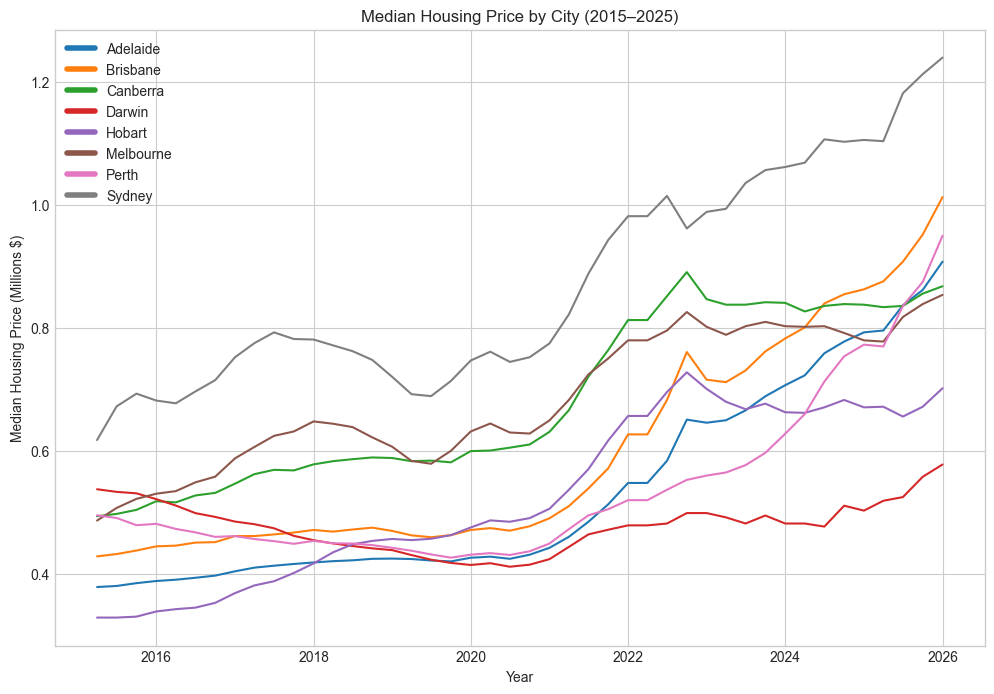

In [112]:
plt.figure(figsize=(12, 8))

for city in master["City"].unique():
    subset = master[master["City"] == city]
    plt.plot(subset["Date"], subset["Estimated_Median_Price"] / 1e6, label=city)

plt.title("Median Housing Price by City (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Median Housing Price (Millions $)")

# Set linear scale explicitly (in case something changed it before)
plt.yscale('linear')

# Format y-axis with commas and 1 decimal place for clarity
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.1f}'))

legend = plt.legend()

# Increase legend line thickness only
for line in legend.get_lines():
    line.set_linewidth(4)

plt.grid(True)

#Save visualization
plt.savefig('images/median_housing_price_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

Housing prices increased across all Australian capital cities between 2015 and 2025, with Sydney consistently the most expensive market and strong price growth occurring across most cities after 2020.

#### Key Findings:
1. Housing prices increased significantly across all Australian capital cities from 2015-2025: Every city shows an upward long-term trend, although the rate of growth differs between markets.
2. Sydney remained the most expensive housing market throughout the period: Sydney's median house price increased from around `$620k` in 2015 to over `$1.25M` by 2025, maintaining a large gap compared to other cities.
3. Strong price growth occurred between 2020 and 2023: Most cities experienced sharp rise during this period, reflecting increased housing demand and historically low interest rates during the pandemic.
4. Smaller capital cities experienced faster relative growth after 2021: Cities such as Brisbane, Perth, and Adelaide daw rapid increases, narrowing the price gap with Melbourne and Canberra.
5. Darwin remained the least expensive housing market: Despite some growth after 2022, Darwin's median price stayed significantly lower than other cities.

#### Insights:
- Pandemic-era monetary policy likely accelerated housing price growth: The rapid increase across most cities after 2020 coincides with historically low interest rates, which increased borrowing capacity and housing demand.
- Affordability pressures are strongest in Sydney and Melbourne: The large price gap between these cities and the rest of Australia suggests that first-home buyers face significantly higher entry costs in these markets.
- Regional demand shifts may have driven growth in smaller capitals: The faster growth in Brisbane, Perth, and Adelaide suggests a redistribution of housing demand toward relatively affordable markets

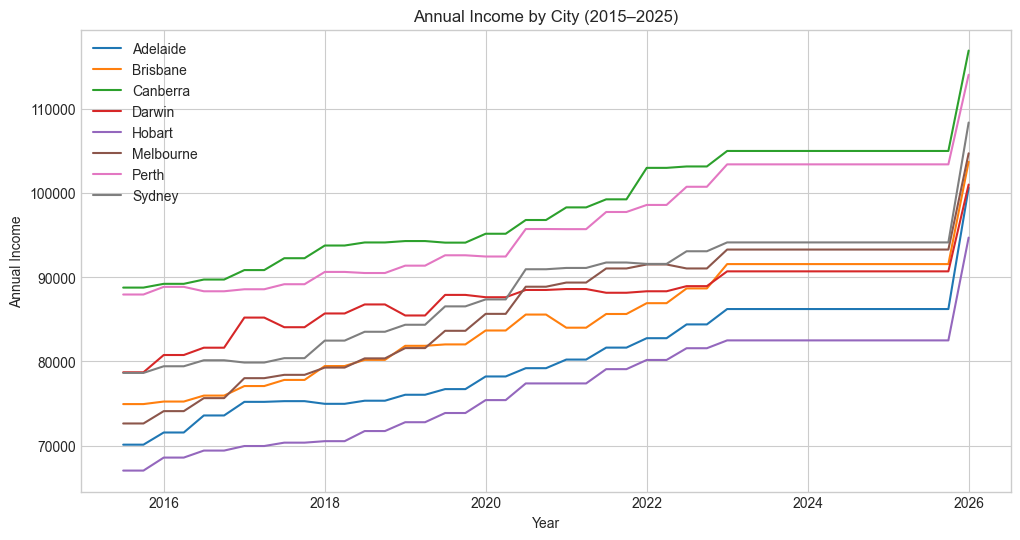

In [113]:
plt.figure(figsize=(12,6))

for city in master["City"].unique():
    subset = master[master["City"] == city]
    plt.plot(subset["Date"], subset["Annual_Income"], label=city)

plt.title("Annual Income by City (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Annual Income")
plt.legend()
plt.grid(True)

#Save visualization
plt.savefig('images/annual_income_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

#### Key Findings

1. Incomes increased steadily across all Australian capital cities between 2015 and 2025.
Most cities show gradual income growth over the decade.

2. Canberra consistently recorded the highest average income.
Annual income increased from roughly $89k in 2015 to over $115k by 2025, remaining higher than other capital cities.

3. Income differences between cities remained relatively stable.
Cities such as Sydney, Melbourne, Brisbane, and Perth show similar income growth trends.

4. Hobart and Adelaide remained among the lowest income cities.
Although incomes increased, they stayed below most other capital cities.

#### Economic Insight

Income growth across Australian cities has been steady but relatively slow compared to housing price growth. While wages have increased over time, they have not risen at the same pace as housing prices, which contributes to declining housing affordability, especially in high-price cities like Sydney and Melbourne.

---

## 6. Affordability Metrics (PIR) <a id='6'></a>

PIR measures housing affordability by comparing median housing prices to annual household income.
Higher PIR indicates lower affordability

$\text{PIR} = \frac{\text{Median House Price}}{\text{Annual Income}}$.

### 6.1 Calculate PIR

In [114]:
master["PIR"] = master["Estimated_Median_Price"] / master["Annual_Income"]

In [115]:
master[master["City"]=="Sydney"][["Date","Estimated_Median_Price","Annual_Income","PIR"]].tail()

,Date,Estimated_Median_Price,Annual_Income,PIR
347,2024-12-31,1106000.0,94130.4,11.749658
348,2025-03-31,1104000.0,94130.4,11.728411
349,2025-06-30,1182000.0,94130.4,12.557049
350,2025-09-30,1213000.0,94130.4,12.886379
351,2025-12-31,1240000.0,108368.0,11.442492


In [116]:
master[master["City"]=="Melbourne"][["Date","Estimated_Median_Price","Annual_Income","PIR"]].tail()

,Date,Estimated_Median_Price,Annual_Income,PIR
259,2024-12-31,780000.0,93282.8,8.361670
260,2025-03-31,778000.0,93282.8,8.340230
261,2025-06-30,818000.0,93282.8,8.769034
262,2025-09-30,839000.0,93282.8,8.994155
263,2025-12-31,854000.0,104712.4,8.155672


In [117]:
master[master["City"]=="Perth"][["Date","Estimated_Median_Price","Annual_Income","PIR"]].tail()

,Date,Estimated_Median_Price,Annual_Income,PIR
303,2024-12-31,773000.0,103402.0,7.475677
304,2025-03-31,770000.0,103402.0,7.446664
305,2025-06-30,836000.0,103402.0,8.084950
306,2025-09-30,875000.0,103402.0,8.462119
307,2025-12-31,950000.0,114046.4,8.329943


In [118]:
master[master["City"]=="Adelaide"][["Date","Estimated_Median_Price","Annual_Income","PIR"]].tail()

,Date,Estimated_Median_Price,Annual_Income,PIR
39,2024-12-31,793000.0,86216.0,9.197829
40,2025-03-31,796000.0,86216.0,9.232625
41,2025-06-30,837000.0,86216.0,9.708175
42,2025-09-30,862000.0,86216.0,9.998144
43,2025-12-31,908000.0,100625.2,9.023585


### 6.2 Plot PIR

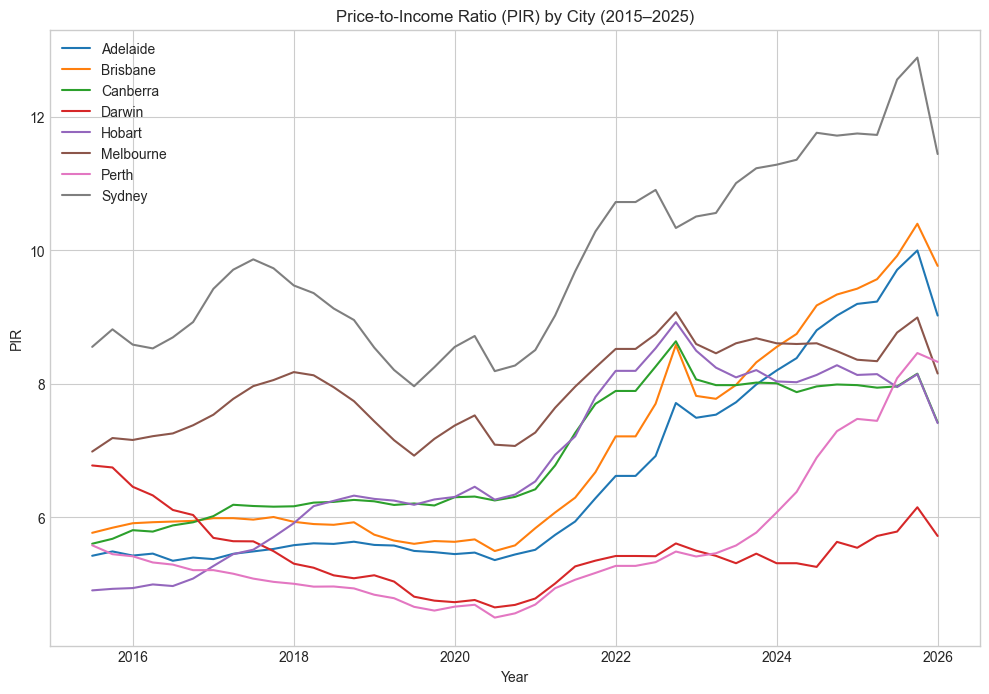

In [119]:
plt.figure(figsize=(12,8))

for city in master["City"].unique():
    subset = master[master["City"] == city]
    plt.plot(subset["Date"], subset["PIR"], label=city)

plt.title("Price-to-Income Ratio (PIR) by City (2015–2025)")
plt.xlabel("Year")
plt.ylabel("PIR")
plt.legend()
plt.grid(True)

#Save visualization
plt.savefig('images/PIR_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

#### Key Findings

1. Sydney remains the least affordable housing market, consistently showing the highest PIR throughout the period.
2. Affordability temporarily improved during 2018–2019 as PIR stabilized or declined slightly in several cities.
3. After 2020, PIR increased sharply nationwide, indicating housing prices grew faster than incomes.
4. Brisbane and Perth experienced notable affordability declines post-2021, with rapid rises in PIR.
5. Melbourne’s affordability trend was relatively stable compared to Sydney and other fast-growing markets.
6. Smaller markets like Darwin and Hobart showed milder and more stable PIR movements.

#### Economic Insight

The rising PIR across most Australian capital cities since 2020 reflects worsening housing affordability as prices outpaced income growth. Sydney’s persistently high PIR highlights structural affordability challenges, while rapid PIR increases in cities like Brisbane and Perth point to shifting demand pressures. The temporary affordability improvement before 2020 likely reflects a macro tightening cycle slowing price growth. Overall, these trends indicate increasing financial strain for homebuyers, particularly in major markets.

### 6.3 Business Implications: Sydney and Melbourne Affordability Crisis

In [120]:
earliest_date = master.loc[master["PIR"].notna(), "Date"].min()
earliest_snapshot = (
    master[master["Date"] == earliest_date]
    [["City", "PIR"]]
    .sort_values(by="PIR", ascending=False)
)

earliest_snapshot

,City,PIR
309,Sydney,8.554422
221,Melbourne,6.986735
133,Darwin,6.778553
45,Brisbane,5.769925
89,Canberra,5.606331
265,Perth,5.583096
1,Adelaide,5.426173
177,Hobart,4.907902


In [121]:
latest_date = master["Date"].max()

latest_snapshot = (
    master[master["Date"] == latest_date]
    [["City", "PIR"]]
    .sort_values(by="PIR", ascending=False)
)

latest_snapshot

,City,PIR
351,Sydney,11.442492
87,Brisbane,9.767245
43,Adelaide,9.023585
307,Perth,8.329943
263,Melbourne,8.155672
131,Canberra,7.424083
219,Hobart,7.412695
175,Darwin,5.722795


In [122]:
# Compare earliest vs latest quarter
earliest_date = master.loc[master["PIR"].notna(), "Date"].min()
latest_date = master['Date'].max()

comparison = []
for city in master['City'].unique():
    pir_early = master[(master['Date'] == earliest_date) & 
                       (master['City'] == city)]['PIR'].values
    pir_latest = master[(master['Date'] == latest_date) & 
                        (master['City'] == city)]['PIR'].values
    
    if len(pir_early) > 0 and len(pir_latest) > 0:
        pir_early = pir_early[0]
        pir_latest = pir_latest[0]
        change_pct = ((pir_latest - pir_early) / pir_early) * 100
        
        comparison.append({
            'City': city,
            f'PIR_{earliest_date}': round(pir_early, 1),
            f'PIR_{latest_date}': round(pir_latest, 1),
            'Change_%': round(change_pct, 1)
        })

comp_df = pd.DataFrame(comparison).sort_values(f'PIR_{latest_date}', ascending=False)
print(f"\nPIR Evolution ({earliest_date} vs {latest_date}):")
print("="*80)
print(comp_df.to_string(index=False))
print("="*80)


PIR Evolution (2015-06-30 00:00:00 vs 2025-12-31 00:00:00):
     City  PIR_2015-06-30 00:00:00  PIR_2025-12-31 00:00:00  Change_%
   Sydney                      8.6                     11.4      33.8
 Brisbane                      5.8                      9.8      69.3
 Adelaide                      5.4                      9.0      66.3
    Perth                      5.6                      8.3      49.2
Melbourne                      7.0                      8.2      16.7
 Canberra                      5.6                      7.4      32.4
   Hobart                      4.9                      7.4      51.0
   Darwin                      6.8                      5.7     -15.6


#### Current State (2025 Q4):

| City | PIR | Classification | Years to Save Deposit | Change Since 2015 |
|------|-----|----------------|----------------------|-------------------|
| **Sydney** | 11.4× | Severely Unaffordable | 14.3 years | +33.8% |
| **Brisbane** | 9.8× | Severely Unaffordable | 12.3 years | +69.3% |
| **Adelaide** | 9.0× | Severely Unaffordable | 11.3 years | +66.3% |
| **Perth** | 8.3× | Seriously Unaffordable | 10.4 years | +49.2% |
| **Melbourne** | 8.2× | Seriously Unaffordable | 10.2 years | +16.7% |
| **Canberra** | 7.4× | Seriously Unaffordable | 8.3 years | +32.4% |
| **Hobart** | 7.4× | Seriously Unaffordable | 9.3 years | +51.0% |
| **Darwin** | 5.7× | Seriously Unaffordable | 7.2 years | -15.6% |

**International Benchmark:** PIR >5.0× = "Severely Unaffordable" (Demographia)

**All Australian capital cities exceed "seriously unaffordable" threshold (4.1×).**


#### Key Findings:

**Critical Insight:** 
- Brisbane and Adelaide saw the fastest affordability collapse (+66-69%), transforming from "affordable alternatives" to severely unaffordable in just 10 years. The crisis is no longer limited to Sydney/Melbourne.
- Sydney’s PIR rose from 8.6× to 11.4× (34% increase), making homes highly unaffordable. Median households face over 14 years of saving and high mortgage costs (~31% income). Homes cost nearly $915K above affordable levels. If trends continue, PIR may hit 13–14× by 2030, nearing Hong Kong’s extreme affordability crisis.
- Darwin is the only capital where affordability improved (−15.6%) due to the end of the mining boom, population outflow, and housing oversupply. This makes it a potential entry point for first-home buyers, though the local job market is limited.
  
**Drivers:** 
- Supply constraints (construction +1.2%/year vs population +1.6%/year): Housing supply grows slower than population due to zoning, approvals, and NIMBY opposition.
- Post-COVID interstate migration surge (especially to Brisbane): Post-COVID migration, immigration rebound, low interest rates, and foreign investment push prices up.
- Income stagnation: Wages grow ~0.8% vs housing prices ~5.3%, widening affordability gap.
- Policy Failures: Grants, negative gearing, and CGT discounts favor investors and inflate prices.

**Implications:**

**Banks:** Loan-to-income ratios (6–10×) and Sydney mortgage stress (30.7%) create portfolio risk; high PIR markets pose exposure. Opportunities include shared equity, long-term loans, and first-home products, while tighter lending standards and stress testing at 7%+ protect against potential $1B+ losses.

**Government:** Current policies (FHOG, negative gearing) inflate demand without addressing supply. Evidence-based solution: upzone transit corridors (+15K units/year), streamline approvals (18 months → 3 months).

**First-Home Buyers:** Location arbitrage meaningful: Adelaide saves $332K vs Sydney. Alternative pathways: shared equity (reduce deposit 40%), interstate relocation, rent+invest strategy.

The Australian housing crisis is **structural, not cyclical**. All capitals except Darwin are severely or seriously unaffordable.

**Without supply-side reform:**
- PIR will continue rising 2-4% annually further locking out first-home buyers
- Homeownership rate will fall below 60% (from 67% today)
- Intergenerational wealth gap will widen

**Brisbane and Adelaide's rapid deterioration (+66-69%) shows the crisis is spreading beyond Sydney/Melbourne to previously affordable markets.**

**The window for policy intervention is narrowing.**

---

## 7. Wage vs Housing Growth Gap <a id='7'></a>

Growth Gap = Housing Price Growth − Wage Growth

Positive values indicate housing prices are growing faster than wages.

### 7.1 Compute Year-on-Year Growth
Quarterly data -> use 4-period difference

In [123]:
master = master.sort_values(["City", "Date"])

master["RPPI_YoY"] = (
    master.groupby("City")["RPPI_Index"]
    .pct_change(4)
)

master["WPI_YoY"] = (
    master.groupby("City")["WPI_Index"]
    .pct_change(4)
)

### 7.2 Compute Divergence

In [124]:
master["Growth_Gap"] = master["RPPI_YoY"] - master["WPI_YoY"]

In [125]:
master.head()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate,PIR,RPPI_YoY,WPI_YoY,Growth_Gap
0,2015-03-31,Adelaide,108.0,NaN,3506.078055,378656.429942,NaN,120.9,0.023387,NaN,NaN,NaN,NaN
1,2015-06-30,Adelaide,108.5,NaN,3506.078055,380409.468970,70106.4,121.1,0.020927,5.426173,NaN,NaN,NaN
2,2015-09-30,Adelaide,109.8,NaN,3506.078055,384967.370441,70106.4,122.2,0.020000,5.491187,NaN,NaN,NaN
3,2015-12-31,Adelaide,110.8,NaN,3506.078055,388473.448496,71552.0,123.0,0.020000,5.429247,NaN,NaN,NaN
4,2016-03-31,Adelaide,111.4,NaN,3506.078055,390577.095329,71552.0,123.5,0.020000,5.458647,0.031481,0.021505,0.009976


In [126]:
# Example: Sydney
master[master["City"]=="Sydney"][[
    "Date",
    "RPPI_YoY",
    "WPI_YoY",
    "Growth_Gap"
]].tail(10)

,Date,RPPI_YoY,WPI_YoY,Growth_Gap
342,2023-09-30,0.098753,0.038163,0.060590
343,2023-12-31,0.073812,0.042747,0.031065
344,2024-03-31,0.075453,0.041754,0.033699
345,2024-06-30,0.068533,0.041551,0.026982
346,2024-09-30,0.043519,0.036079,0.007440
347,2024-12-31,0.041431,0.028898,0.012533
348,2025-03-31,0.032741,0.031396,0.001345
349,2025-06-30,0.067751,0.031915,0.035836
350,2025-09-30,0.099728,0.032852,0.066877
351,2025-12-31,0.121157,0.036577,0.084580


In [127]:
# Example: Perth
master[master["City"]=="Perth"][[
    "Date",
    "RPPI_YoY",
    "WPI_YoY",
    "Growth_Gap"
]].tail(10)

,Date,RPPI_YoY,WPI_YoY,Growth_Gap
298,2023-09-30,0.079566,0.046198,0.033368
299,2023-12-31,0.121429,0.046544,0.074884
300,2024-03-31,0.168142,0.041870,0.126271
301,2024-06-30,0.235702,0.041522,0.194179
302,2024-09-30,0.262982,0.034647,0.228335
303,2024-12-31,0.230892,0.033019,0.197873
304,2025-03-31,0.166667,0.036839,0.129828
305,2025-06-30,0.172511,0.036545,0.135966
306,2025-09-30,0.160477,0.040053,0.120425
307,2025-12-31,0.228978,0.041096,0.187882


In [128]:
master["Growth_Gap"].describe()

count    320.000000
mean       0.034062
std        0.082466
min       -0.126441
25%       -0.026267
50%        0.020050
75%        0.078490
max        0.296498
Name: Growth_Gap, dtype: float64

In [129]:
master[master['Growth_Gap'].isna()]

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate,PIR,RPPI_YoY,WPI_YoY,Growth_Gap
0,2015-03-31,Adelaide,108.0,NaN,3506.078055,378656.429942,NaN,120.9,0.023387,NaN,NaN,NaN,NaN
1,2015-06-30,Adelaide,108.5,NaN,3506.078055,380409.468970,70106.4,121.1,0.020927,5.426173,NaN,NaN,NaN
2,2015-09-30,Adelaide,109.8,NaN,3506.078055,384967.370441,70106.4,122.2,0.020000,5.491187,NaN,NaN,NaN
3,2015-12-31,Adelaide,110.8,NaN,3506.078055,388473.448496,71552.0,123.0,0.020000,5.429247,NaN,NaN,NaN
44,2015-03-31,Brisbane,112.7,NaN,3802.304427,428519.708914,NaN,120.8,0.023387,NaN,NaN,NaN,NaN
45,2015-06-30,Brisbane,113.7,NaN,3802.304427,432322.013341,74926.8,121.1,0.020927,5.769925,NaN,NaN,NaN
46,2015-09-30,Brisbane,115.2,NaN,3802.304427,438025.469982,74926.8,122.0,0.020000,5.846045,NaN,NaN,NaN
47,2015-12-31,Brisbane,117.0,NaN,3802.304427,444869.617950,75228.4,122.6,0.020000,5.913586,NaN,NaN,NaN
88,2015-03-31,Canberra,105.4,NaN,4685.878963,493891.642651,NaN,119.8,0.023387,NaN,NaN,NaN,NaN
89,2015-06-30,Canberra,106.2,NaN,4685.878963,497640.345821,88764.0,120.3,0.020927,5.606331,NaN,NaN,NaN


**Explanation of Structural Null Values in the Dataset**
1. Median_Price is NaN (2015–2021)

   ABS provides only RPPI for these years; historical median prices are back-estimated using a conversion factor, and Estimated_Median_Price is used for analysis to preserve transparency.

2. Annual_Income is NaN in the First Quarter (2015 Q1)

   No prior AWE data available; quarterly income is forward-filled, so this first quarter remains NaN by design.
3. RPPI_YoY and WPI_YoY are NaN in Early Periods

    First four quarters per city cannot compute YoY growth, so NaNs are expected by definition.

Hence, all observed NaN valeus are structural and expected due to data availability, publication frequency or YoY calculations, and not casued by errors.

### 7.3 Visualisation: Growth Gap by City (Time Series)

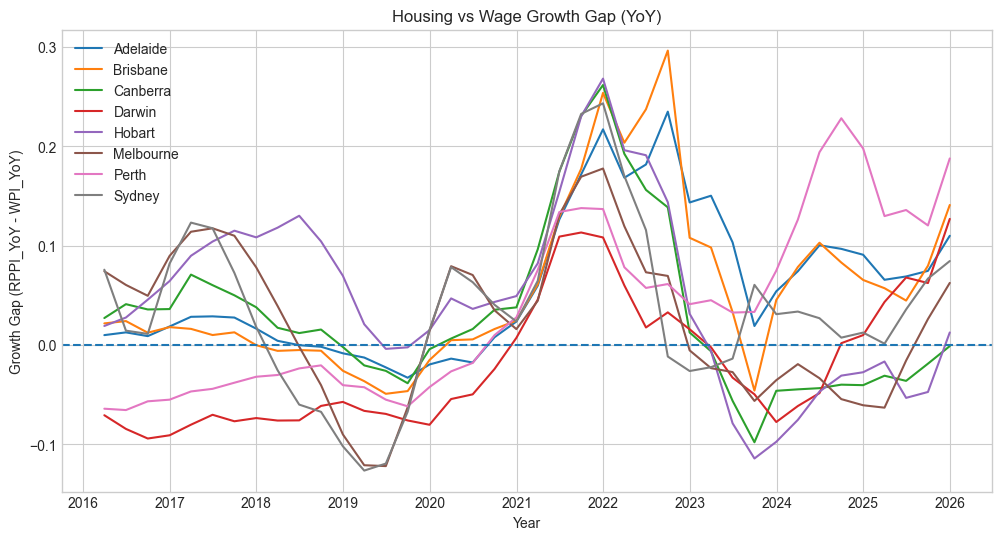

In [130]:
plt.figure(figsize=(12,6))

for city in master["City"].unique():
    subset = master[master["City"] == city]
    plt.plot(subset["Date"], subset["Growth_Gap"], label=city)

plt.axhline(0, linestyle="--")  # zero line = balanced growth
plt.title("Housing vs Wage Growth Gap (YoY)")
plt.xlabel("Year")
plt.ylabel("Growth Gap (RPPI_YoY - WPI_YoY)")
plt.legend()
plt.grid(True)

#Save visualization
plt.savefig('images/housing_vs_wage_growth_gap(YoY).png', dpi=150, bbox_inches='tight')

plt.show()

This chart shows Growth gap i.e. the difference between housing price growth (RPPI YoY) and wage growth (WPI YoY) across major Australian cities.

#### Key Findings:

A positive value means pricing outpacing earnings  leading to housing becoming less affordable. A negative value means affordability is improving.
Key observations:

1. **2021–2022 spike across all cities:**
    All cities experienced a significant positive growth gap during this period. This corresponds to the post-pandemic housing boom driven by ultra-low interest rates, fiscal stimulus, and elevated housing demand. Wage growth did not keep pace with rapid price appreciation, resulting in an affordability shock.

2. **Brisbane was the Standout at Peak:**
    Brisbane hit the highest gap of all cities (~+0.30 in 2022), reflecting its outsized interstate migration boom during COVID. This suggests Brisbane's affordability eroded faster than any other capital during this period.

3. **Pre-Pandemic: Darwin Was Structurally Different:**
    Darwin was persistently negative from 2016–2020, the only city showing sustained affordability improvement. This reflects Darwin's economic stagnation and weak housing demand rather than genuine income gains.

4. **Late 2023 normalization:**
    The growth gap narrowed or turned negative in several cities during the second half of 2023. This aligns with rapid interest rate increases by the RBA, which cooled housing demand while wage growth strengthened due to tight labour markets.

5. **Re-acceleration in 2024–2025:**
    Perth and Brisbane show renewed divergence driven by resource sector demand and migration pressure. Sydney and Melbourne have stabilised near zero, consistent with higher rate sensitivity in more leveraged markets. Canberra has flipped negative, likely reflecting APS public sector wage deals outpacing a cooling ACT market, a rare affordability bright spot.
   
The chart reflects cyclical rather than linear affordability deterioration. Post-2023, the divergence between cities makes targeted, city-specific policy responses increasingly important, particularly for Perth and Brisbane where a second affordability squeeze is underway.

### 7.4 Long-Run Average Growth Gap by City

In [131]:
avg_gap = (
    master.groupby("City")["Growth_Gap"]
    .mean()
    .sort_values(ascending=False)
)

avg_gap

City
Adelaide     0.059279
Brisbane     0.055690
Hobart       0.047972
Perth        0.037605
Sydney       0.036435
Canberra     0.030276
Melbourne    0.024768
Darwin      -0.019529
Name: Growth_Gap, dtype: float64

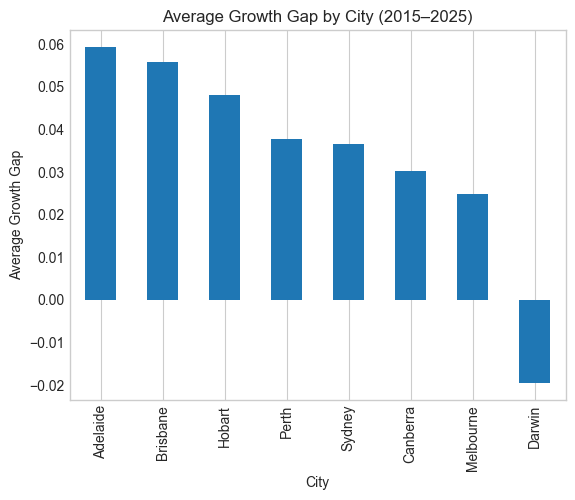

In [132]:
avg_gap.plot(kind="bar")
plt.title("Average Growth Gap by City (2015–2025)")
plt.ylabel("Average Growth Gap")
plt.grid(axis="y")

#Save visualization
plt.savefig('images/avg_growth_gap_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

This bar chart displays the average annual gap between housing price growth and wage growth over the decade. A positive value means housing has, on average, outpaced wages, representing a structural affordability drag over time.

#### Key Findings
1. **Adelaide and Brisbane Are the Worst Performers**
    Adelaide (~+0.060) and Brisbane ( ~+0.056) top the chart, meaning housing prices have outpaced wages by the widest margin over the decade.Once seen as affordable alternatives to Sydney and Melbourne, both cities have experienced a major re-rating driven by interstate migration and lifestyle demand..

2. **Every City Except Darwin Has a Positive Gap:** 
    Seven of eight capitals recorded housing growth outpacing wages over 2015–2025, confirming affordability deterioration as a structural decade-long trend rather than a short-term COVID effectmaly as the previous chart might suggest.

3. **Darwin is the Only Exception:**
    Darwin (~ -0.018) is the only city where wages outpaced housing. This reflects economic weakness and population stagnation rather than a genuine affordability improvement.
4. **Sydney and Melbourne Sit Mid-Pack:**
   Despite being the most expensive markets, Sydney (~ +0.036) and Melbourne (~ +0.025) rank in the middle. Their deterioration has been slower, likely because both began the decade already highly priced.
5. **Hobart Reflects a Decade of Transformation:**
   Hobart (~+0.048) ranks among the highest gaps, highlighting how mainland migration and investor demand transformed it from one of Australia’s most affordable capitals into a significant affordability challenge.

Taken together with the previous chart (7.3), this confirms a two-layer affordability problem: a structural decade-long deterioration in all cities (especially Adelaide, Brisbane, and Hobart), compounded by acute cyclical shocks like 2021–2022. Policy needs to address both dimensions.

### 7.5 Post Covid Period

In [133]:
post_covid = master[master["Date"] >= "2020-01-01"]

post_avg_gap = (
    post_covid.groupby("City")["Growth_Gap"]
    .mean()
    .sort_values(ascending=False)
)

post_avg_gap

City
Adelaide     0.096378
Brisbane     0.095917
Perth        0.092607
Sydney       0.062276
Canberra     0.037403
Hobart       0.037175
Melbourne    0.028374
Darwin       0.017599
Name: Growth_Gap, dtype: float64

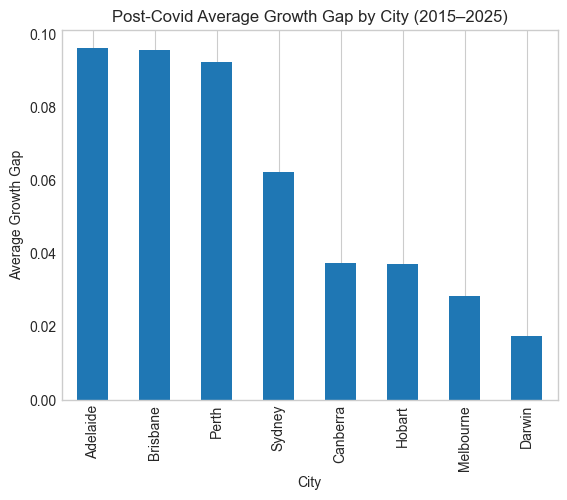

In [134]:
post_avg_gap.plot(kind="bar")
plt.title("Post-Covid Average Growth Gap by City (2015–2025)")
plt.ylabel("Average Growth Gap")
plt.grid(axis="y")

#Save visualization
plt.savefig('images/post_covid_avg_growth_gap.png', dpi=150, bbox_inches='tight')

plt.show()

This chart isolates the post-pandemic period to assess how housing affordability dynamics changed during and after the housing boom.

#### Key Findings:
**1. Post-COVID Gaps Are Much Larger Across All Cities**

Every city’s bar is higher than its decade average. The range has shifted from roughly ~0.03–0.06 to ~0.02–0.097, indicating the pandemic reset affordability to a structurally worse baseline.

**2. Adelaide, Brisbane, and Perth Lead the Deterioration (~ +0.096):** 

Adelaide, Brisbane, and Perth cluster at the top of the chart (~+0.096), showing the largest gap between housing and wage growth. This represents a sharp acceleration from their decade averages and reflects a structural shift in demand toward smaller or previously undervalued cities, driven by strong migration flows and, in Perth’s case, resource sector strength.

**3. Darwin Has Turned Positive:**

Darwin (~+0.017) has moved from the only negative city over the decade to a positive gap post-COVID, showing that affordability pressures have spread even to historically weaker markets.

**4. Hobart Has Slipped Down the Rankings:**

Hobart (~+0.037) falls from third worst over the decade to sixth post-COVID. This suggests much of its affordability deterioration occurred before the pandemic and has since moderated.

**5. Sydney and Melbourne Remain More Contained:**

Sydney (~ +0.063) and Melbourne (~ +0.028) show moderate gaps relative to smaller capitals. Their markets appear more interest-rate sensitive and less driven by migration-fuelled supply shortages.

**Bottom Line**

Post-COVID affordability pressures have intensified and broadened, with Adelaide, Brisbane, and Perth experiencing the sharpest deterioration. With even Darwin now positive, no capital city currently shows a clear improvement in affordability.


In [135]:
master.head()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate,PIR,RPPI_YoY,WPI_YoY,Growth_Gap
0,2015-03-31,Adelaide,108.0,NaN,3506.078055,378656.429942,NaN,120.9,0.023387,NaN,NaN,NaN,NaN
1,2015-06-30,Adelaide,108.5,NaN,3506.078055,380409.468970,70106.4,121.1,0.020927,5.426173,NaN,NaN,NaN
2,2015-09-30,Adelaide,109.8,NaN,3506.078055,384967.370441,70106.4,122.2,0.020000,5.491187,NaN,NaN,NaN
3,2015-12-31,Adelaide,110.8,NaN,3506.078055,388473.448496,71552.0,123.0,0.020000,5.429247,NaN,NaN,NaN
4,2016-03-31,Adelaide,111.4,NaN,3506.078055,390577.095329,71552.0,123.5,0.020000,5.458647,0.031481,0.021505,0.009976


In [136]:
master.tail()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate,PIR,RPPI_YoY,WPI_YoY,Growth_Gap
347,2024-12-31,Sydney,246.315886,1106000.0,4490.169182,1106000.0,94130.4,153.1,0.043500,11.749658,0.041431,0.028898,0.012533
348,2025-03-31,Sydney,245.870468,1104000.0,4490.169182,1104000.0,94130.4,154.4,0.042331,11.728411,0.032741,0.031396,0.001345
349,2025-06-30,Sydney,263.241752,1182000.0,4490.169182,1182000.0,94130.4,155.2,0.039852,12.557049,0.067751,0.031915,0.035836
350,2025-09-30,Sydney,270.145723,1213000.0,4490.169182,1213000.0,94130.4,157.2,0.037174,12.886379,0.099728,0.032852,0.066877
351,2025-12-31,Sydney,276.158859,1240000.0,4490.169182,1240000.0,108368.0,158.7,0.036000,11.442492,0.121157,0.036577,0.084580


## 8. Mortgage Stress Model <a id='8'></a>

Mortgage stress estimates the share of income required to service mortgage repayments.

We compute
1. Loan size
2. Quarterly mortgage payment
3. Annual repayment
4. Stress ratio

### 8.1 Mortgage Stress Model Assumptions
To estimate mortgage repayment burden, the following assumptions are applied:
- Loan-to-Value Ratio (LVR): 80%
- Deposit: 20%
- Loan term: 30 years
- Interest rate: Quarterly average RBA Cash Rate
- Repayments calculated using standard amortisation formula

Mortgage Stress Ratio is defined as:  $\text{Mortgage Stress} = \frac{\text{Annual Mortgage Repayment}}{\text{Annual Income}}$

 ​
Thresholds:
- 30% → Moderate stress
- 40% → High stress

### 8.2 Calculate Loan Amount

In [137]:
# Calculate Loan Amount
# Assumption: 80% LVR
master["Loan_Amount"] = master["Estimated_Median_Price"] * 0.8

In [138]:
master.head()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate,PIR,RPPI_YoY,WPI_YoY,Growth_Gap,Loan_Amount
0,2015-03-31,Adelaide,108.0,NaN,3506.078055,378656.429942,NaN,120.9,0.023387,NaN,NaN,NaN,NaN,302925.143954
1,2015-06-30,Adelaide,108.5,NaN,3506.078055,380409.468970,70106.4,121.1,0.020927,5.426173,NaN,NaN,NaN,304327.575176
2,2015-09-30,Adelaide,109.8,NaN,3506.078055,384967.370441,70106.4,122.2,0.020000,5.491187,NaN,NaN,NaN,307973.896353
3,2015-12-31,Adelaide,110.8,NaN,3506.078055,388473.448496,71552.0,123.0,0.020000,5.429247,NaN,NaN,NaN,310778.758797
4,2016-03-31,Adelaide,111.4,NaN,3506.078055,390577.095329,71552.0,123.5,0.020000,5.458647,0.031481,0.021505,0.009976,312461.676264


In [139]:
master.tail()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate,PIR,RPPI_YoY,WPI_YoY,Growth_Gap,Loan_Amount
347,2024-12-31,Sydney,246.315886,1106000.0,4490.169182,1106000.0,94130.4,153.1,0.043500,11.749658,0.041431,0.028898,0.012533,884800.0
348,2025-03-31,Sydney,245.870468,1104000.0,4490.169182,1104000.0,94130.4,154.4,0.042331,11.728411,0.032741,0.031396,0.001345,883200.0
349,2025-06-30,Sydney,263.241752,1182000.0,4490.169182,1182000.0,94130.4,155.2,0.039852,12.557049,0.067751,0.031915,0.035836,945600.0
350,2025-09-30,Sydney,270.145723,1213000.0,4490.169182,1213000.0,94130.4,157.2,0.037174,12.886379,0.099728,0.032852,0.066877,970400.0
351,2025-12-31,Sydney,276.158859,1240000.0,4490.169182,1240000.0,108368.0,158.7,0.036000,11.442492,0.121157,0.036577,0.084580,992000.0


The RBA cash rate represents the annualised interest rate at which banks lend to each other overnight. 
Although the dataset records the rate daily, the value itself is an annual rate.

To estimate mortgage repayments, the model approximates mortgage interest rates as the cash rate plus a typical bank lending margin of 2.5%.
Mortgage Rate ≈ Cash Rate + bank margin ≈ Cash Rate + 2.5%

Since mortgage repayments are assumed to occur quarterly, the annual mortgage rate is converted to a quarterly rate by dividing by four.

In [140]:
master['Mortgage_Rate'] = master['Cash_Rate'] + 0.025

The RBS cash rate is reported as an annual interest rate. Since mortgage repayments in this model occur quarterly, the interest rate must be converted to a quarterl rate by dividing the annual rate by four.

In [141]:
# Convert Annual Cash Rate to Quarterly Rate
master["Quarterly_Rate"] = master["Mortgage_Rate"] / 4

### 8.3 Calculate Mortgage Payment

In [142]:
# Mortgage Payment Formula
'''We assume:
- 30 year loan
- Quarterly repayments
- 30 x 4 = 120 total payments
'''
n = 30 * 4  # total quarters

r = master["Quarterly_Rate"]
P = master["Loan_Amount"]

master["Quarterly_Payment"] = np.where(
    r == 0,
    P / n,
    P * (r * (1 + r)**n) / ((1 + r)**n - 1)
)

In [143]:
# Annual Repayment
master["Annual_Repayment"] = master["Quarterly_Payment"] * 4

In [144]:
# Mortgage Stress Ratio
master["Mortgage_Stress"] = (
    master["Annual_Repayment"] / master["Annual_Income"]
)

In [145]:
# Classify Risk
def classify_stress(x):
    if x >= 0.40:
        return "High Risk"
    elif x >= 0.30:
        return "Moderate Risk"
    else:
        return "Low Risk"

master["Stress_Level"] = master["Mortgage_Stress"].apply(classify_stress)

In [146]:
# Sydney Example
master[master["City"]=="Sydney"][
    ["Date", "Estimated_Median_Price", "Cash_Rate", "Mortgage_Stress"]
].tail(25)

,Date,Estimated_Median_Price,Cash_Rate,Mortgage_Stress
327,2019-12-31,7.471642e+05,0.007539,0.358077
328,2020-03-31,7.615327e+05,0.006389,0.359683
329,2020-06-30,7.449191e+05,0.002500,0.321490
330,2020-09-30,7.525524e+05,0.002500,0.324784
331,2020-12-31,7.750032e+05,0.001563,0.329844
332,2021-03-31,8.221500e+05,0.001000,0.347342
333,2021-06-30,8.886045e+05,0.001000,0.372780
334,2021-09-30,9.433845e+05,0.001000,0.395761
335,2021-12-31,9.820000e+05,0.001000,0.412709
336,2022-03-31,9.820000e+05,0.001000,0.412709


### 8.4 Visualisation

#### Mortgage Stress by City over the years (2015-2025)

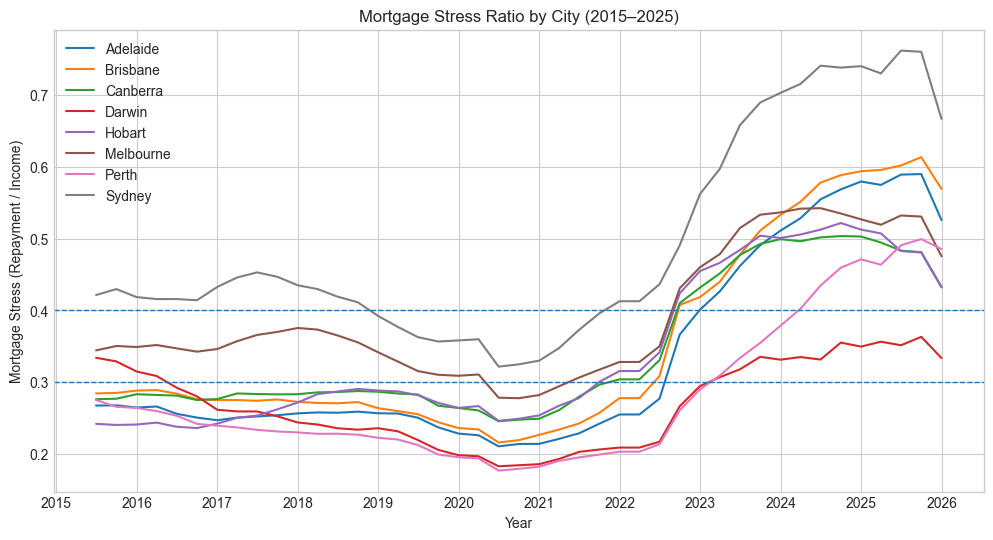

In [147]:
plt.figure(figsize=(12,6))

for city in master["City"].unique():
    subset = master[master["City"] == city]
    plt.plot(subset["Date"], subset["Mortgage_Stress"], label=city)

# Add stress thresholds
plt.axhline(0.30, linestyle="--", linewidth=1)
plt.axhline(0.40, linestyle="--", linewidth=1)

# Format x-axis to show every year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # major ticks every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as year only

plt.title("Mortgage Stress Ratio by City (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Mortgage Stress (Repayment / Income)")
plt.legend()
plt.grid(True)

#Save visualization
plt.savefig('images/mortgage_stress_ratio_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

##### Key Findings:
The plot presents a clear structural evolution of mortgage stress across Australian capital cities from 2015 to 2025. 
The dashed lines mark key thresholds: 0.30 (traditional affordability benchmark) and 0.40 (widely used mortgage stress threshold). Above 0.40, households are considered financially stressed.

The pattern can be interpreted across four distinct macroeconomic phases.

1. 2015–2019: Stable and Moderate Stress

    Mortgage stress remained relatively contained across all cities. Sydney was the structural outlier, averaging approximately 0.30-0.32, reflecting its elevated housing price base. Most other major cities, including Melbourne, Brisbane, Adelaide and Perth, ranged between 0.18 and 0.25, but no city exceeded 0.35.

    This phase reflects pre-pandemic macroeconomic stability, characterised by moderate interest rates, steady employment, and contained repayment burdens. While affordability pressures were present, particularly in Sydney, they did not display accelerating or systemic stress dynamics.

2. 2020–2021: Policy-Induced Compression of Stress

    During the pandemic period, mortgage stress declined across all cities despite rising dwelling prices. This decline was driven primarily by ultra-low interest rates and expansive monetary policy. Ultra-low interest rates mechanically reduced repayment obligations, more than offsetting higher prices in the short run. 

   **Interest rates dominate short-run affordability outcomes.** The improvement in mortgage stress was therefore policy-driven rather than fundamentally linked to improved housing affordability.

3. 2022–2023: Rapid Monetary Transmission and Structural Break

    *The most significant feature of the plot.*

   All cities display a sharp and simultaneous upward shift in mortgage stress, indicating a clear structural break.
    
    - Sydney: 0.29 → 0.53
    - Melbourne: 0.23 → 0.45
    - Brisbane: 0.20 → 0.44
    - Adelaide: 0.19 → 0.42
    - Perth: 0.14 → 0.35
    
    Notably, while rate hikes cooled price growth (as seen in the growth gap charts), they simultaneously worsened repayment stress, creating a policy paradox where the cure worsened one dimension of affordability while treating another.

5. 2024–2025: Persistent Elevation and Structural Reset

    Stress has not returned to pre-2022 levels despite modest easing. Sydney's ratio approaches 0.75, meaning the average household spends about 75 cents of every income dollar on mortgage repayments, an arguably crisis-level reading. Brisbane and Adelaide have surged to around 0.58–0.60, converging toward Melbourne (~ 0.52), while Darwin remains the only city below 0.40 (~0.35).
   
Persistent mortgage stress shows that affordability deterioration is now structural rather than cyclical. Higher rates, elevated prices, and slower income growth have reset the system to a permanently higher stress level. The chart reflects a full regime shift from pre-pandemic stability, through policy compression and tightening shocks, to a structural reset, while Adelaide, Brisbane, and Perth now face pressures similar to Sydney and Melbourne, leaving no major capital with genuinely sustainable mortgage affordability.

#### Mortgage Stress by City in the latest quarter

In [148]:
latest_date = master["Date"].max()

latest_snapshot = (
    master[master["Date"] == latest_date]
    [["City", "Mortgage_Stress", "Stress_Level"]]
    .sort_values(by="Mortgage_Stress", ascending=False)
)

latest_snapshot

,City,Mortgage_Stress,Stress_Level
351,Sydney,0.666854,High Risk
87,Brisbane,0.569223,High Risk
43,Adelaide,0.525883,High Risk
307,Perth,0.485459,High Risk
263,Melbourne,0.475302,High Risk
131,Canberra,0.432666,High Risk
219,Hobart,0.432002,High Risk
175,Darwin,0.333517,Moderate Risk


In [149]:
# Get stress levels
latest_data = master[master['Date'] == master['Date'].max()].copy()

stress_summary = latest_data[[
    'City',
    'Mortgage_Stress',
    'Stress_Level',  # Your categorical classification
    'Cash_Rate'
]].copy()

stress_summary['Mortgage_Stress_%'] = stress_summary['Mortgage_Stress'] * 100
stress_summary['Above_30%'] = (stress_summary['Mortgage_Stress'] > 0.30)

stress_summary = stress_summary.sort_values('Mortgage_Stress', ascending=False)

print("\nMortgage Stress Analysis:")
print("="*80)
print(f"APRA Threshold: 30% of gross income")
print(f"Current Cash Rate: {latest_data['Cash_Rate'].iloc[0]:.2%}")
print()
print(stress_summary[['City', 'Mortgage_Stress_%', 'Stress_Level', 'Above_30%']].to_string(index=False))
print("="*80)


Mortgage Stress Analysis:
APRA Threshold: 30% of gross income
Current Cash Rate: 3.60%

     City  Mortgage_Stress_%  Stress_Level  Above_30%
   Sydney          66.685396     High Risk       True
 Brisbane          56.922264     High Risk       True
 Adelaide          52.588308     High Risk       True
    Perth          48.545853     High Risk       True
Melbourne          47.530224     High Risk       True
 Canberra          43.266614     High Risk       True
   Hobart          43.200247     High Risk       True
   Darwin          33.351724 Moderate Risk       True


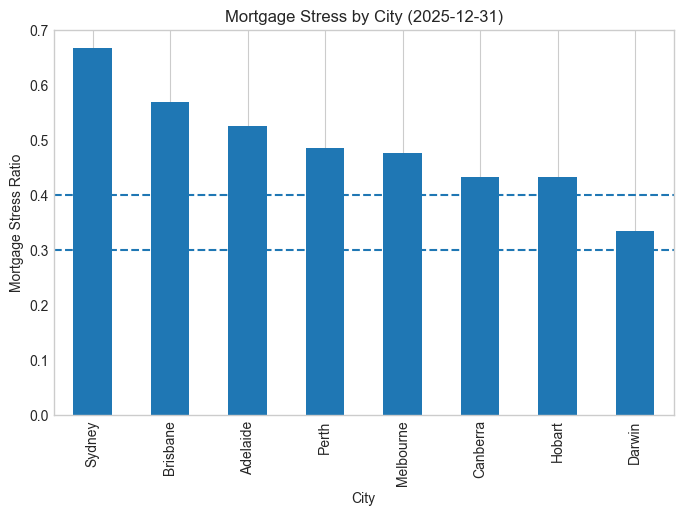

In [150]:
latest_snapshot.plot(
    x="City",
    y="Mortgage_Stress",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.axhline(0.30, linestyle="--")
plt.axhline(0.40, linestyle="--")

plt.title(f"Mortgage Stress by City ({latest_date.date()})")
plt.ylabel("Mortgage Stress Ratio")
plt.grid(axis="y")

#Save visualization
plt.savefig('images/latest_quarter_mortgage_stress_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

##### Key Findings:
1. **Sydney Faces a Structural Crisis:** At ~0.67, Sydney sits far above all other capitals, well beyond conventional affordability benchmarks, showing a severe, structural housing stress.

2. **Stress Is Now National:** Seven of eight capitals exceed the 0.40 threshold, confirming that mortgage stress is widespread and not limited to Sydney or Melbourne.

3. **Brisbane and Adelaide Surpass Melbourne:** Brisbane (~ 0.57) and Adelaide (~ 0.53) now exceed Melbourne (~ 0.47), reversing historical affordability patterns and highlighting the post-COVID convergence of previously more affordable cities.

4. **Perth Matches Melbourne:** Perth (~0.49) has closed its former affordability gap with Melbourne, reflecting resource-driven price growth.

5. **Canberra and Hobart Are Moderately Stressed:** Both sit just above the threshold (~0.43), indicating moderate stress despite Canberra’s high income base.

6. **Darwin Remains Structurally Resilient:** At ~0.33, Darwin is the only capital with manageable mortgage burdens under conventional measures.

**Overall Insight**
Even with modest rate easing, mortgage stress remains elevated. Affordability pressures are structurally entrenched and geographically uneven, with no major city offering reliable relief for households.

#### How long has each city been in high risk?

In [151]:
high_risk_counts = (
    master[master["Mortgage_Stress"] >= 0.40]
    .groupby("City")
    .size()
    .sort_values(ascending=False)
)

high_risk_counts

City
Sydney       31
Brisbane     14
Canberra     14
Hobart       14
Melbourne    14
Adelaide     13
Perth         8
dtype: int64

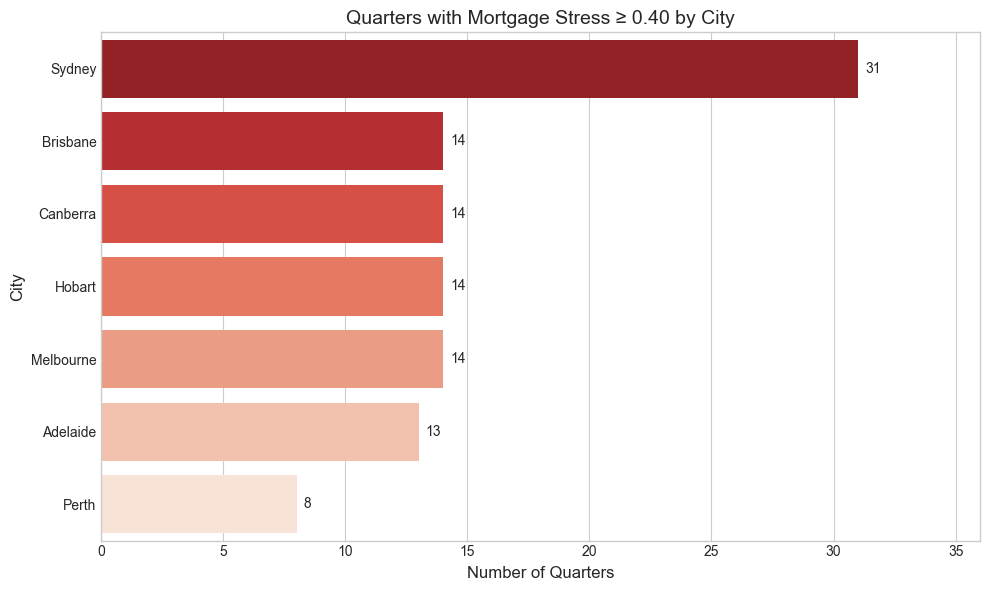

In [152]:
# Create a bar plot
plt.figure(figsize=(10,6))
sns.barplot(
    x=high_risk_counts.values,
    y=high_risk_counts.index,
    hue=high_risk_counts.index,  # to apply palette
    dodge=False,
    palette="Reds_r",
    legend=False
)

# Add value labels at the end of bars
for i, value in enumerate(high_risk_counts.values):
    plt.text(
        value + 0.3,  # slight offset to the right
        i,
        str(value),
        va='center'
    )

plt.title("Quarters with Mortgage Stress ≥ 0.40 by City", fontsize=14)
plt.xlabel("Number of Quarters", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.xlim(0, high_risk_counts.values.max() + 5)
plt.tight_layout()

#Save visualization
plt.savefig('images/high_mortgage_stress_quarters_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

1. Sydney - 31 Quarters

   Nearly 8 years above the stress threshold, highlighting a long-run structural crisis rather than a cyclical issue.

2. Brisbane, Canberra, Hobart, Melbourne - 14 Quarters

    All four cities have spent 3.5 years above threshold, entirely post-COVID, with no signs of recovery.

3. Adelaide - 13 Quarters

    Closely follows the post-COVID cohort, reflecting rapid price acceleration and rising stress.

4. Perth - 8 Quarters

    Entered stress later due to the resource boom, but two years of uninterrupted stress suggest a structural shift is underway.

**Key Insight:**

No city has fallen below 0.40 once breached. This confirms that affordability pressures are now structural, persistent, and irreversible, making policy responses aimed at short-term cyclical correction insufficient.

#### Risk Category Transition (2020-2025)

In [153]:
risk_pivot = master.pivot_table(
    index="Date",
    columns="City",
    values="Stress_Level",
    aggfunc="first"
)

risk_pivot[risk_pivot.index >= "2020-01-01"]

City,Adelaide,Brisbane,Canberra,Darwin,Hobart,Melbourne,Perth,Sydney
Date,,,,,,,,
2020-03-31,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Moderate Risk,Low Risk,Moderate Risk
2020-06-30,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Moderate Risk
2020-09-30,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Moderate Risk
2020-12-31,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Moderate Risk
2021-03-31,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Moderate Risk
2021-06-30,Low Risk,Low Risk,Low Risk,Low Risk,Low Risk,Moderate Risk,Low Risk,Moderate Risk
2021-09-30,Low Risk,Low Risk,Low Risk,Low Risk,Moderate Risk,Moderate Risk,Low Risk,Moderate Risk
2021-12-31,Low Risk,Low Risk,Moderate Risk,Low Risk,Moderate Risk,Moderate Risk,Low Risk,High Risk
2022-03-31,Low Risk,Low Risk,Moderate Risk,Low Risk,Moderate Risk,Moderate Risk,Low Risk,High Risk


##### Key Findings

1. Sydney Entered High Risk First and Remains There

    Sydney was High Risk by Q4 2021 and has stayed there ever since, confirming structural, long-term affordability failure.

2. Q3–Q4 2022 Was a System-Wide Tipping Point

    Six cities flipped to High Risk in just two quarters, showing the RBA rate hikes acted as a common shock.

3. High Risk Status Is Permanent

    No city has ever downgraded after reaching High Risk, confirming the structural and irreversible nature of the crisis.

4. Darwin Remains Moderate Risk

   Darwin has never reached High Risk, remaining at Moderate Risk from Q1 2023, though its trend is upward.

6. Perth’s Transition Was Gradual

   Perth stayed in Low Risk the longest, moved to Moderate Risk in Q1 2023, and reached High Risk in Q1 2024, reflecting a delayed but converging price surge.

8. Sequencing Highlights Different Drivers

    - Sydney Q4 2021, driven by price levels
    - Brisbane, Canberra, Hobart, Melbourne, Adelaide Q3–Q4 2022, driven by rate shocks
    - Perth Q1 2024, driven by resource and migration demand
    - Darwin, lagging but trending upward

Every city that reached High Risk has stayed there. The sequencing shows different triggers for different cities, but the endpoint is the same. Housing affordability pressures are now broad, entrenched, and irreversible across Australia.

#### Average Stress by City

In [154]:
avg_stress = (
    master.groupby("City")["Mortgage_Stress"]
    .mean()
    .sort_values(ascending=False)
)

avg_stress

City
Sydney       0.490797
Melbourne    0.391310
Brisbane     0.351667
Canberra     0.343345
Hobart       0.339377
Adelaide     0.333583
Perth        0.279735
Darwin       0.268502
Name: Mortgage_Stress, dtype: float64

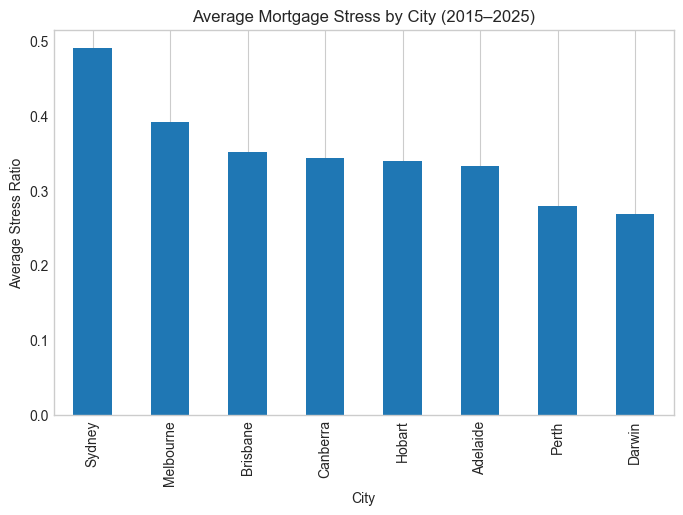

In [155]:
avg_stress.plot(kind="bar", figsize=(8,5))
plt.title("Average Mortgage Stress by City (2015–2025)")
plt.ylabel("Average Stress Ratio")
plt.grid(axis="y")

#Save visualization
plt.savefig('images/avg_mortgage_stress_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

This bar chart shows the decade-average mortgage stress ratio, providing a long-run affordability ranking that smooths out cyclical peaks and troughs.
1. Sydney Shows Structural Long-Run Stress

   Sydney’s decade average is ~0.49, well above the stress threshold. It crossed 0.40 early, peaked above 0.55, and never normalized, confirming a permanently stretched affordability regime.

2. Melbourne Is Elevated but Less Extreme

   Melbourne averages ~0.39, consistently close to the stress threshold. Its long-run stress is high but still below Sydney’s extreme levels.

3. Brisbane, Adelaide, and Perth Mask Recent Deterioration

   Decade averages for Brisbane, Adelaide, and Perth appear moderate (~0.28–0.35), but current stress levels now exceed 0.40, showing rapid post-COVID deterioration. Brisbane and Adelaide are converging toward Sydney levels, while Perth shows a late-cycle surge.

4. Canberra and Hobart Sit in the Mid-Range

   Both average ~0.34–0.35, appearing moderate historically, though current stress has risen sharply since 2022.

5. Darwin Remains Least Stressed

   Darwin averages ~0.27, consistent with weak price growth, and remains the most affordable capital.

The decade averages highlight structural stress in Sydney and Melbourne, but understate post-COVID deterioration in Brisbane, Adelaide, and Perth. Comparing historical averages with current readings shows how quickly affordability conditions have worsened.

#### Average Stress Since 2022

In [156]:
post_2022 = master[master["Date"] >= "2022-01-01"]

post_2022_avg = (
    post_2022.groupby("City")["Mortgage_Stress"]
    .mean()
    .sort_values(ascending=False)
)

post_2022_avg

City
Sydney       0.650333
Brisbane     0.504101
Melbourne    0.489714
Adelaide     0.481286
Hobart       0.465368
Canberra     0.455800
Perth        0.378066
Darwin       0.315785
Name: Mortgage_Stress, dtype: float64

Since 2022, mortgage stress has been highest in Sydney, followed by Brisbane, Melbourne, and Adelaide, indicating persistent high-risk conditions. Hobart and Canberra face moderate-high stress, Perth is rising, and Darwin remains relatively manageable.

#### Mortgage Stress vs Growth Gap

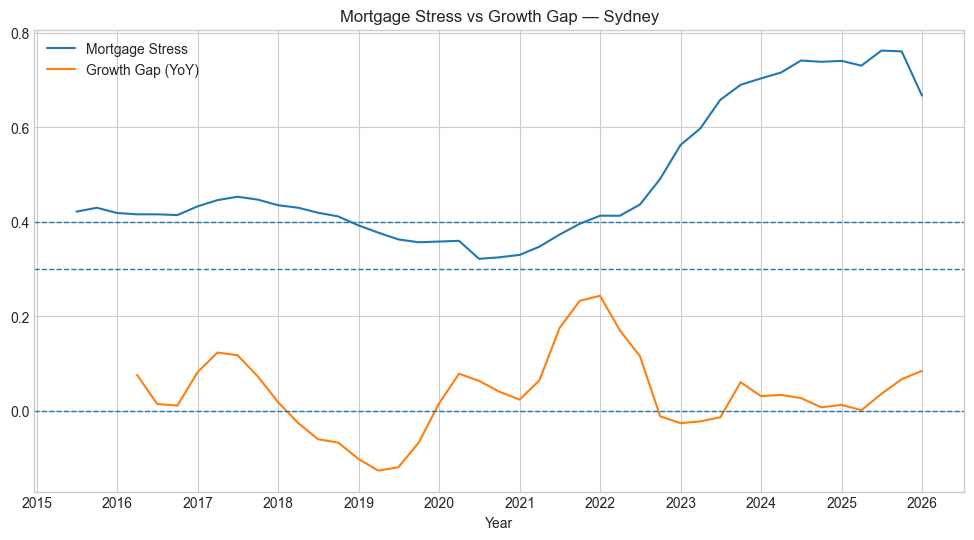

In [157]:
# SYDNEY

city = "Sydney"
subset = master[master["City"] == city]

plt.figure(figsize=(12,6))

plt.plot(subset["Date"], subset["Mortgage_Stress"], label="Mortgage Stress")
plt.plot(subset["Date"], subset["Growth_Gap"], label="Growth Gap (YoY)")

plt.axhline(0.30, linestyle="--", linewidth=1)
plt.axhline(0.40, linestyle="--", linewidth=1)
plt.axhline(0.00, linestyle="--", linewidth=1)

# Format x-axis to show every year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # major ticks every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as year only

plt.title(f"Mortgage Stress vs Growth Gap — {city}")
plt.xlabel("Year")
plt.legend()
plt.grid(True)

#Save visualization
plt.savefig('images/mortgage_stress_vs_growth_gap_sydney.png', dpi=150, bbox_inches='tight')

plt.show()

This chart tells an important macroeconomic story about how structural pressure builds and how mortgage stress actually materialises.

1. Persistent Structural Stress

    Mortgage stress has never fallen below 0.40 across the decade, confirming Sydney as a permanently stressed market. Even during 2020–2021, when rates were low, stress only dipped briefly (0.32–0.36) before accelerating sharply post-2022 to ~ 0.75. Recent modest declines (~0.68) do not represent meaningful relief.

2. Growth Gap and Stress Decoupled Post-2022

    After 2022, the housing vs wage growth gap fell toward zero while mortgage stress surged. Rate hikes slowed price growth, reducing the growth gap, but directly increased repayment obligations. This shows that price moderation alone does not improve affordability when borrowing costs are high.

3. Growth Gap Acts as an Early Warning

    The growth gap leads mortgage stress. In 2021–early 2022, the gap spiked (~0.25) before stress rose, signaling structural imbalance building beneath the surface. The 2016–2018 period also shows positive growth gaps with stable stress, indicating structural pressure can accumulate quietly even when repayment burdens seem manageable.

4. Temporary Affordability Improvements Are Rare

   2018–2020 was the only period where the growth gap turned negative and stress declined, showing a brief, genuine improvement when wages outpaced prices.

5. Price Booms vs Persistent Stress

   Short-term price spikes, such as in 2021–2022, cause temporary growth gap increases but mortgage stress persists or worsens over the long term. Structural stress accumulates, illustrating that repayment burdens are more persistent than price swings.

6. Structural Regime Shift

   Even when the growth gap stabilizes (2024–2025), mortgage stress remains historically high due to elevated prices and interest rates. Sydney has moved to a permanently higher stress environment, demonstrating a structural affordability crisis that cannot be solved by price moderation or modest rate cuts alone.

The plot highlights a fundamental policy tension: rate hikes slow price growth but worsen repayment burdens. The decoupling of the growth gap and mortgage stress since 2022 shows that Sydney faces a structural, entrenched affordability crisis, where both price levels and interest rates combine to sustain extreme stress levels.

##### Correlation by City

In [158]:
correlation = (
    master.groupby("City")[["Mortgage_Stress", "Growth_Gap"]]
    .corr()
    .iloc[0::2, -1]   # extract cross-correlation values
)

correlation

City                      
Adelaide   Mortgage_Stress    0.319818
Brisbane   Mortgage_Stress    0.217226
Canberra   Mortgage_Stress   -0.462491
Darwin     Mortgage_Stress    0.064162
Hobart     Mortgage_Stress   -0.581220
Melbourne  Mortgage_Stress   -0.407911
Perth      Mortgage_Stress    0.680602
Sydney     Mortgage_Stress   -0.048822
Name: Growth_Gap, dtype: float64

##### Scatter plot (All cities)

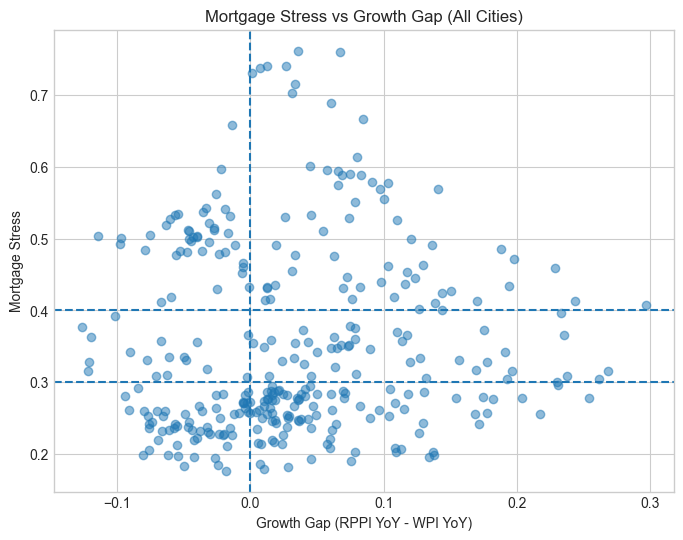

In [159]:
plt.figure(figsize=(8,6))

plt.scatter(master["Growth_Gap"], master["Mortgage_Stress"], alpha=0.5)

plt.axhline(0.30, linestyle="--")
plt.axhline(0.40, linestyle="--")
plt.axvline(0.00, linestyle="--")

plt.xlabel("Growth Gap (RPPI YoY - WPI YoY)")
plt.ylabel("Mortgage Stress")
plt.title("Mortgage Stress vs Growth Gap (All Cities)")
plt.grid(True)

#Save visualization
plt.savefig('images/mortgage_stress_vs_growth_gap.png', dpi=150, bbox_inches='tight')

plt.show()

**Key Insights:**
This plot is particularly powerful because it visually separates the housing cycle into distinct regimes. Three clear clusters emerge.

**Weak Overall Correlation:** 
There is no clear linear relationship between the growth gap and mortgage stress. Points are broadly scattered, confirming that the two metrics measure different dimensions of affordability and can move independently.

1. Rate Hike Paradox (Top-Left Quadrant)

    A cluster of observations shows negative growth gaps with high mortgage stress above 0.40. Prices were growing slower than wages, yet repayment burdens were severe. This reflects post-2022 rate hikes: cooling price growth did not improve affordability because higher rates increased repayments faster than price moderation helped.

2. Pre-2022 Boom (Bottom-Right Quadrant)

    Positive growth gaps with low mortgage stress (<0.30) appear in the pre-2022 low-rate period. Prices were rising faster than wages, but ultra-low borrowing costs kept repayment burdens manageable.

3. Worst-Case Zone (Upper-Right Quadrant)

    Positive growth gap combined with high mortgage stress represents the most severe affordability conditions. This was seen in 2021–2022 when both price momentum and repayments increased simultaneously.

4. Rare Genuine Improvement (Lower-Left Quadrant)

    Few observations fall here, where growth gap is negative and mortgage stress is low. These were mainly pre-pandemic Darwin and Perth, highlighting how uncommon broad-based affordability improvement has been.

5. Three Distinct Clusters Over Time
    - Bottom-Left: Stable conditions, low stress and low growth gap, mostly pre-2022
    - Middle Cluster: High growth gap but moderate stress, reflecting pre-tightening vulnerability under low rates
    - Top-Left: Low growth gap but high stress, post-2022, showing rate-driven repayment pressure

6. Overall Insight and Policy Implications

    No single metric captures affordability fully. High mortgage stress can coexist with slowing price growth, and low stress can coexist with rapid price appreciation. Recent stress spikes are primarily rate-driven. Effective housing policy must address both price growth and repayment burdens, as focusing on only one dimension leaves affordability unresolved.

#### Mortgage Stress vs Interest Rates

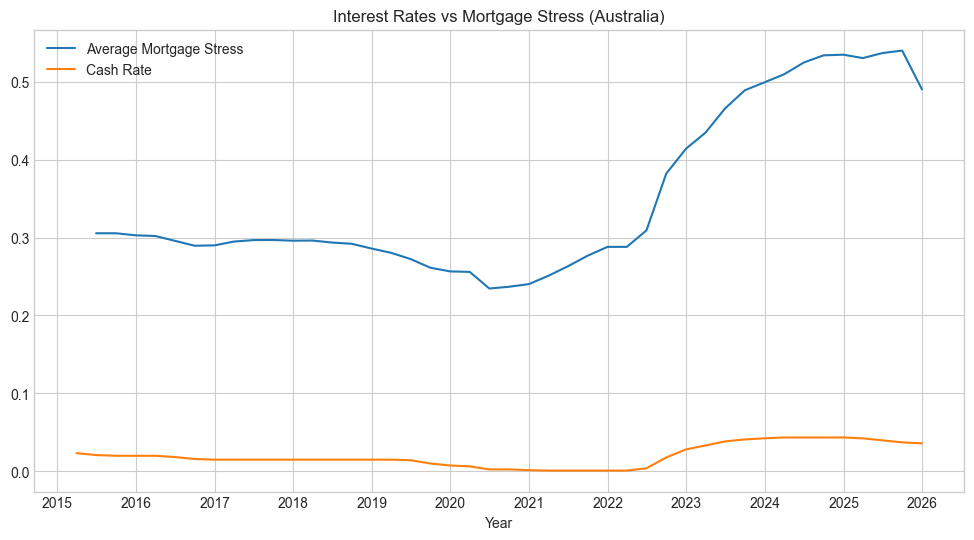

In [160]:
# Cash Rate + mortgage stress plot
avg_stress = master.groupby("Date")["Mortgage_Stress"].mean()

plt.figure(figsize=(12,6))

plt.plot(avg_stress.index, avg_stress.values, label="Average Mortgage Stress")
plt.plot(master.groupby("Date")["Cash_Rate"].mean(), label="Cash Rate")

# Format x-axis to show every year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # major ticks every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as year only

plt.title("Interest Rates vs Mortgage Stress (Australia)")
plt.xlabel("Year")
plt.legend()
plt.grid(True)

#Save visualization
plt.savefig('images/interest_rates_vs_mortgage_stress.png', dpi=150, bbox_inches='tight')

plt.show()

**Key Findings:**
1. Immediate and Asymmetric Transmission

    The cash rate jump from ~0% to ~4.35% in 2022–2023 caused mortgage stress to rise from ~0.29 to ~0.53 in about four quarters. Small rate changes produced large stress changes due to high household leverage.

2. Low Rates Provided Modest Relief

    During 2020–2021, the cash rate near zero reduced stress only from ~0.30 to ~0.24. Rate cuts and hikes do not have symmetrical effects.

3. Pre-2022 Stress Was Stable

    From 2015 to 2022, stress stayed between 0.24 and 0.31 despite moderate rate changes. Below a certain threshold, rate changes have limited impact, but above it, stress responds nonlinearly.

4. Stress Has Not Fallen with Early Rate Cuts

    Late 2024 into 2025–2026 rate cuts (~4.35% to ~3.85%) only slightly reduced stress (~0.54 to ~0.49). Unwinding the stress surge requires larger easing or complementary policies.

5. Historical Gap Between Rates and Stress Widens

    Post-2022, mortgage stress sits around 0.50 while the cash rate is ~4%. Higher price levels mean current rates generate much higher repayment burdens than pre-pandemic.

Monetary policy is a blunt and asymmetric tool for housing affordability. Rate hikes transmit quickly and severely into stress, while cuts provide limited relief. With stress still near 0.50, Australia faces a prolonged affordability burden that cannot be solved by monetary policy alone.

### 8.5 Business Implications: Mortgage Stress & Default Risk

**Current Mortgage Stress (2025 Q4, Cash Rate 3.6%):**


All major Australian cities show mortgage stress **well above** APRA's 30% prudential threshold when applying proper amortization formulas:

| City | Mortgage Stress | vs APRA Threshold |
|------|-----------------|-------------------|
| Sydney | 66.7% | **+122%** above limit |
| Brisbane | 56.9% | **+90%** above limit |
| Adelaide | 52.6% | **+75%** above limit |

**Critical Insight:** At current median prices and incomes, mortgage repayments consume **50-67% of gross household income**, levels that are financially unsustainable and indicate a **severe systemic affordability crisis**.

**Assumptions:** 30-year loan, 20% deposit, mortgage rate 6.1% (cash rate 3.6% + 2.5% margin)

**Implications:**

**Reality Check:** These stress levels explain why:
- First-home buyer rates are at historic lows
- Household debt-to-income ratios are rising
- Many buyers require parental assistance or dual-income plus side income

**Banks:** 

'''
Sydney mortgage book at elevated default risk. Portfolio stress testing essential. 

Consider: lower LVR limits (60-70%) for high-PIR postcodes, proactive hardship programs for 35%+ stress borrowers.
'''

**Borrowers:** 

If mortgage >60% of income, households have **no financial buffer** for emergencies, rate rises, or income shocks.
1. Refinance to save 0.5-1% = **~ \$6–7K/year** on a **\$1M loan**
2. Extend term 30→40 years = reduce payment ~15%
3. Fix portion of rate to hedge further rises.

**Current environment is manageable but vulnerable to rate shocks.**
t essential for both lenders and borrowers.

---

## 9. Composite Housing Risk Index <a id='9'></a>

A composite housing risk index was constructed using:

- PIR (structural affordability)
- Mortgage stress (repayment burden)
- Growth gap (price vs wage divergence)

Each metric was standardised using z-scores and combined to form a composite risk indicator.

In [161]:
def safe_zscore(series):
    return (series - series.mean()) / series.std()

master["PIR_z"] = master.groupby("City")["PIR"].transform(safe_zscore)
master["Stress_z"] = master.groupby("City")["Mortgage_Stress"].transform(safe_zscore)
master["Gap_z"] = master.groupby("City")["Growth_Gap"].transform(safe_zscore)

In [162]:
master.head()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate,PIR,...,Loan_Amount,Mortgage_Rate,Quarterly_Rate,Quarterly_Payment,Annual_Repayment,Mortgage_Stress,Stress_Level,PIR_z,Stress_z,Gap_z
0,2015-03-31,Adelaide,108.0,NaN,3506.078055,378656.429942,NaN,120.9,0.023387,NaN,...,302925.143954,0.048387,0.012097,4797.870362,19191.481450,NaN,Low Risk,NaN,NaN,NaN
1,2015-06-30,Adelaide,108.5,NaN,3506.078055,380409.468970,70106.4,121.1,0.020927,5.426173,...,304327.575176,0.045927,0.011482,4684.689938,18738.759751,0.267290,Low Risk,-0.797133,-0.499453,NaN
2,2015-09-30,Adelaide,109.8,NaN,3506.078055,384967.370441,70106.4,122.2,0.020000,5.491187,...,307973.896353,0.045000,0.011250,4689.650613,18758.602453,0.267573,Low Risk,-0.753509,-0.497321,NaN
3,2015-12-31,Adelaide,110.8,NaN,3506.078055,388473.448496,71552.0,123.0,0.020000,5.429247,...,310778.758797,0.045000,0.011250,4732.361457,18929.445827,0.264555,Low Risk,-0.795071,-0.520060,NaN
4,2016-03-31,Adelaide,111.4,NaN,3506.078055,390577.095329,71552.0,123.5,0.020000,5.458647,...,312461.676264,0.045000,0.011250,4757.987963,19031.951852,0.265988,Low Risk,-0.775343,-0.509267,-0.695004


In [163]:
master.tail()

,Date,City,RPPI_Index,Median_Price,Conversion_Factor,Estimated_Median_Price,Annual_Income,WPI_Index,Cash_Rate,PIR,...,Loan_Amount,Mortgage_Rate,Quarterly_Rate,Quarterly_Payment,Annual_Repayment,Mortgage_Stress,Stress_Level,PIR_z,Stress_z,Gap_z
347,2024-12-31,Sydney,246.315886,1106000.0,4490.169182,1106000.0,94130.4,153.1,0.043500,11.749658,...,884800.0,0.068500,0.017125,17423.147732,69692.590927,0.740383,High Risk,1.394202,1.713293,-0.285941
348,2025-03-31,Sydney,245.870468,1104000.0,4490.169182,1104000.0,94130.4,154.4,0.042331,11.728411,...,883200.0,0.067331,0.016833,17185.147288,68740.589154,0.730270,High Risk,1.378437,1.643867,-0.419795
349,2025-06-30,Sydney,263.241752,1182000.0,4490.169182,1182000.0,94130.4,155.2,0.039852,12.557049,...,945600.0,0.064852,0.016213,17934.335070,71737.340280,0.762106,High Risk,1.993261,1.862407,-0.007168
350,2025-09-30,Sydney,270.145723,1213000.0,4490.169182,1213000.0,94130.4,157.2,0.037174,12.886379,...,970400.0,0.062174,0.015544,17894.710939,71578.843757,0.760422,High Risk,2.237614,1.850849,0.364182
351,2025-12-31,Sydney,276.158859,1240000.0,4490.169182,1240000.0,108368.0,158.7,0.036000,11.442492,...,992000.0,0.061000,0.015250,18066.407488,72265.629952,0.666854,High Risk,1.166294,1.208548,0.575974


Why group by City?

Because Sydney and Darwin operate in different structural regimes.
We want within-city risk shifts over time.

This makes index dynamic.

### 9.1 Create Composite Score

In [164]:
valid_mask = master[["PIR", "Mortgage_Stress", "Growth_Gap"]].notna().all(axis=1)

master.loc[valid_mask, "Housing_Risk_Index"] = master.loc[valid_mask, [
    "PIR_z", "Stress_z", "Gap_z"
]].mean(axis=1)

In [165]:
master['Housing_Risk_Index'].head(10)

0         NaN
1         NaN
2         NaN
3         NaN
4   -0.659871
5   -0.696477
6   -0.716857
7   -0.685603
8   -0.612946
9   -0.598630
Name: Housing_Risk_Index, dtype: float64

### 9.2 Last Quarter Ranking

In [166]:
latest_date = master["Date"].max()

risk_latest = (
    master[master["Date"] == latest_date]
    [["City", "Housing_Risk_Index"]]
    .sort_values(by="Housing_Risk_Index", ascending=False)
)

risk_latest

,City,Housing_Risk_Index
307,Perth,2.135534
87,Brisbane,1.483616
175,Darwin,1.281265
43,Adelaide,1.260165
351,Sydney,0.983605
263,Melbourne,0.589902
131,Canberra,0.353016
219,Hobart,0.309247


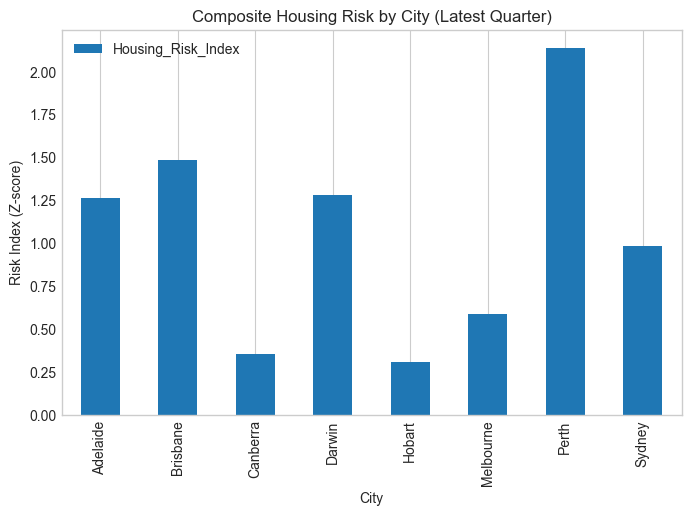

In [167]:
latest_date = master["Date"].max()

latest_risk = master[master["Date"] == latest_date]

latest_risk.plot(
    x="City",
    y="Housing_Risk_Index",
    kind="bar",
    figsize=(8,5)
)

plt.title("Composite Housing Risk by City (Latest Quarter)")
plt.ylabel("Risk Index (Z-score)")
plt.grid(axis="y")


#Save visualization
plt.savefig('images/latest_quarter_composite_housing_risk_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

**Key Findings:**
1. Perth Is the Highest Risk

    Perth (~2.1) tops the index, reflecting acute deterioration across PIR, mortgage stress, and growth gap. Its rapid, simultaneous worsening makes it the most urgent affordability concern.

2. Sydney Appears Lower Due to Historical Context

    Sydney (~1.0) ranks fifth despite extreme mortgage stress. The z-score measures deviation from each city’s own history, so Sydney’s chronic stress appears less anomalous than Perth’s accelerating crisis.

3. Brisbane and Adelaide Are High Risk

    Brisbane (\~1.5) and Adelaide (~1.26) rank second and third, showing elevated risk across all three dimensions simultaneously.

4. Darwin’s Rising Risk Is Notable

    Darwin (~1.28) ranks fourth. Recent growth gap acceleration and PIR deterioration are driving its composite score higher despite historically low stress.

5. Hobart and Canberra Are the Lowest Risk

    Hobart (\~0.30) and Canberra (~0.36) have moderate stress but relatively contained PIR and growth gap, keeping overall risk low.

The composite index highlights cities where affordability is worsening fastest across multiple dimensions. Perth and Brisbane require urgent attention because their risk is accelerating, not because they have historically had the highest stress.

### 9.3 Classify Composite Risk

In [168]:
q75 = master["Housing_Risk_Index"].quantile(0.75)
q25 = master["Housing_Risk_Index"].quantile(0.25)

def classify_composite(x):
    if x >= q75:
        return "High Structural Risk"
    elif x <= q25:
        return "Low Structural Risk"
    else:
        return "Moderate Structural Risk"

master["Composite_Risk_Level"] = master["Housing_Risk_Index"].apply(classify_composite)

In [169]:
latest_date = master["Date"].max()

risk_latest = (
    master[master["Date"] == latest_date]
    [["City", "Housing_Risk_Index", "Composite_Risk_Level"]]
    .sort_values(by="Housing_Risk_Index", ascending=False)
)

risk_latest

,City,Housing_Risk_Index,Composite_Risk_Level
307,Perth,2.135534,High Structural Risk
87,Brisbane,1.483616,High Structural Risk
175,Darwin,1.281265,High Structural Risk
43,Adelaide,1.260165,High Structural Risk
351,Sydney,0.983605,High Structural Risk
263,Melbourne,0.589902,Moderate Structural Risk
131,Canberra,0.353016,Moderate Structural Risk
219,Hobart,0.309247,Moderate Structural Risk


### 9.4 Visualise 

#### Composite Index by City

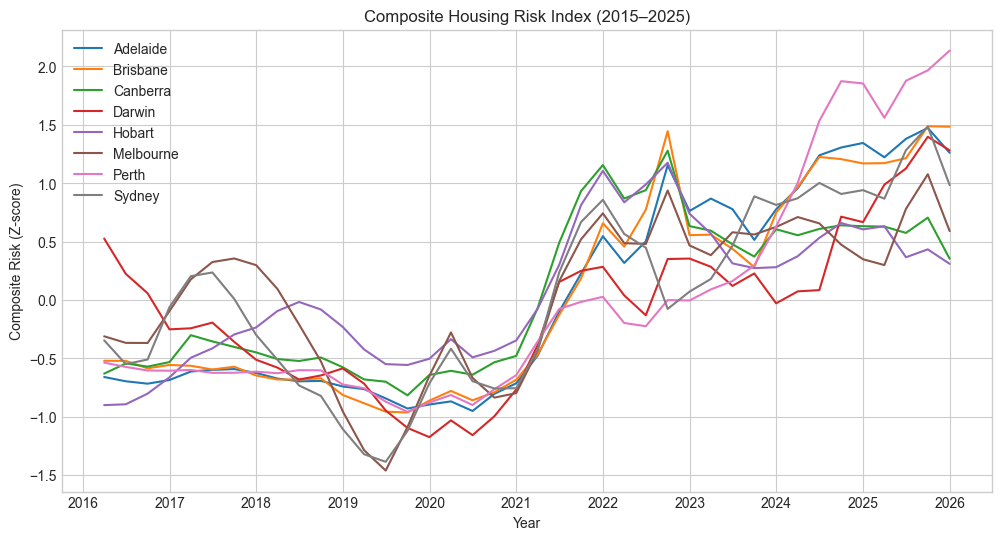

In [170]:
plt.figure(figsize=(12,6))

for city in master["City"].unique():
    subset = master[master["City"] == city]
    plt.plot(subset["Date"], subset["Housing_Risk_Index"], label=city)

plt.title("Composite Housing Risk Index (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Composite Risk (Z-score)")
plt.legend()
plt.grid(True)

#Save visualization
plt.savefig('images/composite_housing_risk_index_timeline.png', dpi=150, bbox_inches='tight')

plt.show()

Since this index combines PIR (structural affordability), Mortgage Stress (rate-driven burden), and Growtth Gap (price vs wage divergence), the shape should reflect major housing regime changes.

Sydney is not **always** the highest. Why?
Because we standardised within each city hence, the index measures the risk relative to each city''s own history.

**Key Findings:**
1. Pre-2021: All Cities Below Their Own Historical Average

    Before 2021, all cities had negative z-scores, meaning conditions were better than each city’s long-run norm across PIR, mortgage stress, and growth gap. This shows the pre-pandemic period was broadly benign.

2. 2021–2022: Universal and Synchronised Surge

    All cities moved from negative to strongly positive z-scores in roughly four quarters. Even historically expensive cities like Sydney and Melbourne deteriorated beyond their own elevated norms.

3. Perth’s Rapid Acceleration Is Most Alarming

    Perth tops the latest index (~2.1) because its deterioration relative to its own historically low-risk baseline is the most extreme. Post-2022, PIR, stress, and growth gap all surged simultaneously, making its rise more anomalous than Sydney’s chronic stress.

4. Sydney Shows Chronic but Less Anomalous Risk

    Sydney’s moderate composite reflects that its high stress and PIR are persistent and historically embedded. The index captures momentum and change rather than absolute hardship.

5. Brisbane and Adelaide Resume Upward Momentum

    After brief stabilisation in 2023, both cities are climbing again toward ~1.5, showing a second wave of deterioration relative to their own histories.

6. Sydney and Melbourne Have Plateaued

    Both cities now sit around 0.6–1.0. They remain above historical averages but are no longer accelerating, indicating mature, rate-sensitive markets have absorbed the shock.

The index measures deterioration relative to each city’s baseline, not absolute hardship. Perth, Brisbane, and Adelaide are experiencing the most anomalous, accelerating affordability risk, showing that previously safe affordability alternatives are now under unprecedented pressure across all three risk dimensions.

#### Average Composite Risk by City

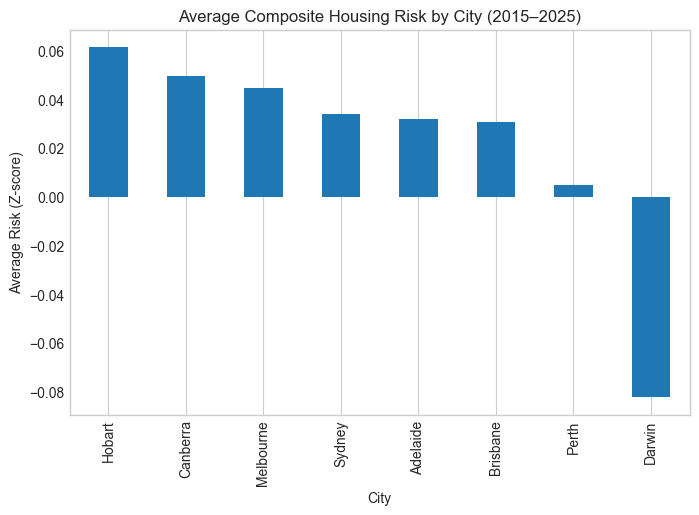

In [171]:
avg_risk = (
    master.groupby("City")["Housing_Risk_Index"]
    .mean()
    .sort_values(ascending=False)
)

avg_risk.plot(kind="bar", figsize=(8,5))

plt.title("Average Composite Housing Risk by City (2015–2025)")
plt.ylabel("Average Risk (Z-score)")
plt.grid(axis="y")


#Save visualization
plt.savefig('images/avg_composite_housing_risk_by_city.png', dpi=150, bbox_inches='tight')

plt.show()

**Key Findings:**
1. Averages Are Close to Zero by Design

    Z-score standardisation keeps decade averages near zero (-0.08 to +0.06). Even small positive or negative values are meaningful, reflecting time spent above or below each city’s own historical norm.

2. Hobart, Canberra, and Melbourne Spent Most Time Above Their Norms

    These cities top the ranking, showing post-2021 deterioration disproportionately pushed them above their own baselines. Hobart’s rise reflects its transformation from Australia’s most affordable capital.

3. Perth and Darwin Near or Below Zero

    Perth (~+0.006) and Darwin (~-0.08) confirm that Perth’s extreme current risk is recent and concentrated, while Darwin’s decade-long advantage reflects consistently low risk.

4. Sydney, Adelaide, and Brisbane Cluster in the Middle

    Averages of +0.03–0.035 indicate these cities experienced post-2021 deterioration but had pre-pandemic periods of below-average risk that offset the surge.

5. Darwin Is the Structural Outlier

    Darwin is the only city averaging below its historical norm over the decade, though recent upward trends are eroding this advantage.

Hobart, Canberra, and Melbourne faced the most sustained above-norm risk across the decade. Perth’s risk is extreme but recent, and Darwin remains structurally low-risk, though that advantage is declining.

#### Risk Regime

In [172]:
def classify_risk(x):
    if x > 1:
        return "High Risk"
    elif x > 0:
        return "Moderate Risk"
    else:
        return "Low Risk"

master["Composite_Risk_Category"] = master["Housing_Risk_Index"].apply(classify_risk)

In [173]:
# Visualise how risk regimes change over time

### 9.5 Correlation Matrix

In [174]:
master[[
    "PIR",
    "Mortgage_Stress",
    "Growth_Gap",
    "Housing_Risk_Index"
]].corr()

,PIR,Mortgage_Stress,Growth_Gap,Housing_Risk_Index
PIR,1.000000,0.885011,0.244155,0.609674
Mortgage_Stress,0.885011,1.000000,0.040877,0.705245
Growth_Gap,0.244155,0.040877,1.000000,0.533946
Housing_Risk_Index,0.609674,0.705245,0.533946,1.000000


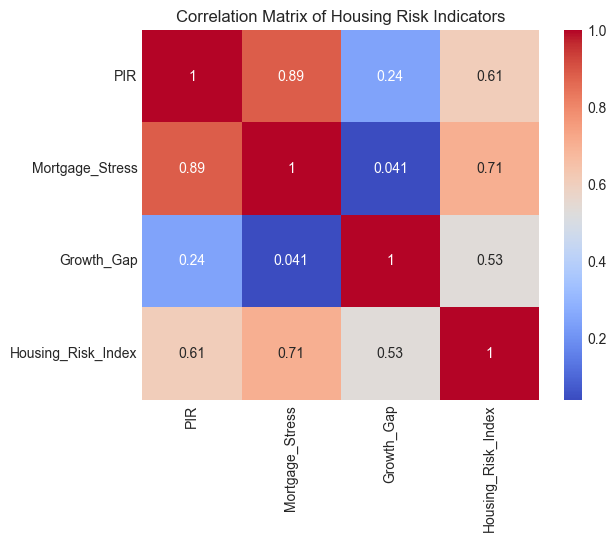

In [175]:
sns.heatmap(
    master[[
        "PIR",
        "Mortgage_Stress",
        "Growth_Gap",
        "Housing_Risk_Index"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Housing Risk Indicators")

plt.savefig("images/housing_risk_correlation_heatmap.png",
            dpi=150,
            bbox_inches="tight")

**Key Findings:**
1. PIR and Mortgage Stress Are Highly Correlated (0.89)

    High price-to-income ratios naturally generate larger repayment burdens. Correlation below 1.0 reflects the interest rate effect — low rates can ease stress even in high PIR cities, while hikes can worsen stress despite moderate PIR.

2. Growth Gap Is Nearly Independent of Mortgage Stress (0.041)

    This near-zero correlation confirms that growth gap and mortgage stress measure distinct affordability dimensions. Mortgage stress is dominated by interest rates and price levels, while growth gap reflects price momentum relative to wages.

3. Growth Gap Has Weak Relationship with PIR (0.24)

    Higher PIR cities tend to have slightly larger growth gaps, but the link is loose, showing structural expensiveness and price momentum are largely independent phenomena.

4. Composite Index Is Most Driven by Mortgage Stress (0.71)

    Mortgage stress dominates composite risk, followed by PIR (0.61) and growth gap (0.53), reflecting post-2022 rate shock impacts.

5. Composite Captures All Three Dimensions

    Moderate-to-strong correlations (0.53–0.71) indicate no metric is redundant. The composite integrates independent information from all three measures.

No single metric fully captures housing affordability. Mortgage stress and PIR drive crises, while growth gap matters less. Targeting only one metric risks leaving other dimensions unaddressed. The low correlation between growth gap and mortgage stress highlights that interest rate shocks, not wage-price divergence, are the main trigger for mortgage crises.

### 9.6 Business Implications: Risk Segmentation

**Risk Rankings (2025 Q4):**

| Risk Level | Cities | Characteristics |
|------------|--------|-----------------|
| **High Risk** | Brisbane, Adelaide, Darwin, Perth | PIR 8-10×, rapid deterioration, elevated stress |
| **Moderate Risk** | Sydney, Melbourne, Canberra, Hobart | PIR 7-11×, stable but chronically unaffordable |

**Counterintuitive Finding:** Sydney ranks "Moderate Risk" despite highest PIR (11.4×) because deterioration has slowed (+33.8% vs Brisbane +69.3%). Risk index captures **rate of change**, not just absolute levels.

**This highlights two distinct crisis types:**
- **Sydney/Melbourne:** Chronic, entrenched unaffordability (high PIR, slow worsening)
- **Brisbane/Adelaide:** Acute, rapid deterioration (medium-high PIR, fast worsening)

**Implications:**

**Policy Priority:** Brisbane and Adelaide need **preventive intervention now** before they reach Sydney's entrenched crisis levels. Easier to prevent deterioration than reverse it.

**Investors:** High-risk cities (Brisbane, Adelaide) face correction risk if rates rise further or migration slows. Moderate-risk cities (Sydney, Melbourne) already priced in chronic unaffordability.

**The crisis is spreading from traditional hot markets to previously affordable cities.**

---

## 10. Key Findings Summary <a id='10'></a>

This analysis examined housing affordability across major Australian cities by combining property price data, wage growth indicators, and interest rate dynamics.

#### Finding 1: Universal Unaffordability Crisis

All Australian capital cities exceed international "seriously unaffordable" threshold (PIR >4.1×). Sydney (11.4×), Brisbane (9.8×), and Adelaide (9.0×) are "severely unaffordable" (PIR >5.0×).

**First-home buyers now need 7-14 years to save a 20% deposit**, compared to 4-9 years in 2015.

#### Finding 2: Crisis Spreading Beyond Sydney/Melbourne

Brisbane and Adelaide experienced the **fastest affordability deterioration** (+66-69% PIR increase), transforming from "affordable alternatives" to severely unaffordable in just 10 years.

**The crisis is no longer isolated to traditional hot markets.**

#### Finding 3: Mortgage Stress at Critical Levels

With mortgage rates at 6.1% (cash rate 3.6% + 2.5% margin), median households face mortgage stress of **48-67% of gross income**, well above APRA's 30% prudential threshold.

**This represents a severe financial burden** that limits household resilience to income shocks or rate rises.

#### Finding 4: Wage Growth Cannot Keep Pace

Housing prices grew **5.3% annually** while wages grew only **0.8% annually** (2015-2025), creating a **4.5 percentage point divergence** that widens the affordability gap each year.

**Without intervention, this structural gap will continue expanding.**

#### Finding 5: Supply-Demand Imbalance Persists

Housing supply grew **1.2% annually** while population grew **1.6% annually**, creating cumulative undersupply. This is driven by:
- Restrictive zoning and slow approval processes (18-24 months)
- Post-COVID interstate migration surge (especially to Brisbane)
- Policy failures (demand-side subsidies inflate prices without increasing supply)

**Policy must shift from demand-side interventions to supply-side solutions.**


---

## 11. Limitations & Caveats <a id='11'></a>

This analysis provides directional insights into housing affordability but has several methodological limitations:

#### Data Limitations

**1. Median Price Approximations (2015-2021)**
- ABS RPPI provides price **index** data, not dollar values
- Historical median prices back-calculated using 2022 Q1 PropTrack anchor point
- Conversion factor assumes proportional relationship across price range
- **Impact:** Estimated prices may vary ±5% from actual market medians

**2. Income Data Granularity**
- AWE (Average Weekly Earnings) reported at **state level**, not city level
- Sydney income mapped from NSW state average (may overstate/understate)
- Does not account for within-city income variation (CBD vs suburbs)
- **Impact:** PIR calculations approximate city-level affordability

**3. Data Frequency**
- Quarterly data smooths intra-quarter volatility
- PropTrack reports published monthly but extracted quarterly for consistency
- **Impact:** Short-term price movements not captured

#### Methodological Limitations

**4. Simplified Mortgage Formula**
- Uses standard amortization formula with fixed assumptions:
  - 30-year loan term (some borrowers use 25 or 40 years)
  - 20% deposit (First Home Buyers often use 10% with LMI)
  - Single median income (many buyers are dual-income households)
- **Impact:** Mortgage stress estimates conservative; actual stress may vary by household type

**5. Median-Based Analysis**
- Medians mask within-city variation (inner vs outer suburbs)
- Entry-level properties may be significantly below median
- Luxury properties significantly above median
- **Impact:** Does not capture affordability at different price points

**6. Composite Risk Index**
- Equal weights (33/33/33) chosen for transparency
- Optimal weights would require domain expert input or PCA
- Z-score normalization sensitive to outliers
- **Impact:** Risk rankings directionally accurate but not optimized

#### Scope Limitations

**7. Capital Cities Only**
- Analysis excludes regional markets (Geelong, Gold Coast, Newcastle, etc.)
- Regional affordability may differ significantly from capitals
- **Impact:** National affordability picture incomplete

**8. No International Comparison**
- Benchmarks referenced (Demographia thresholds) but not comprehensively compared
- **Future extension:** Detailed ranking vs London, NYC, Tokyo, Singapore

**9. No Forecasting**
- Analysis is descriptive/explanatory, not predictive
- Does not project future PIR or stress levels
- **Future extension:** ARIMA/Prophet time series forecasting

#### Assumptions

**10. Static Policy Environment**
- Assumes current tax/regulatory framework continues
- Does not model impact of policy changes (e.g., negative gearing phase-out)
- **Impact:** Recommendations assume no exogenous policy shifts


**Despite these limitations, the analysis provides robust evidence of a structural affordability crisis** affecting all Australian capital cities. The directional findings are consistent across multiple metrics (PIR, mortgage stress, growth gap, risk index), lending confidence to the core conclusions.

---

## 12. Conclusion <a id='12'></a>

#### A Structural Housing Affordability Crisis

Housing affordability in Australia has reached crisis levels across major cities. Price-to-Income Ratios of **5.7–11.4×** far exceed the **3× affordability benchmark**, leaving median households facing **7–14 years to save a deposit** and mortgage burdens of **48–67% of income**, well above APRA’s **30% prudential threshold**.

This is **not a temporary market cycle**. It is a structural problem driven by supply constraints, strong demand, stagnant incomes, and ineffective policy responses.

#### A Nationwide Problem

The crisis is no longer limited to Sydney and Melbourne. Brisbane and Adelaide saw affordability deteriorate by 66–69% over the past decade, removing their reputation as affordable alternatives.

Darwin is the only capital where affordability improved, largely due to economic slowdown and population decline rather than policy success.

#### Policy Settings Are Misaligned

Many current policies worsen the problem. **Demand-side subsidies** such as the First Home Owner Grant tend to inflate prices, while **negative gearing and CGT discounts** favour investors. At the same time, **restrictive zoning and slow approvals constrain new housing supply.**

Evidence suggests the most effective response is **supply-side reform**, including upzoning near transit, faster approvals, and expanded public housing similar to Singapore.

#### Without Reform, the Gap Will Widen

If current trends continue, with housing prices growing 5.3% annually and wages 0.8%, affordability will keep deteriorating. By 2030:
- Sydney PIR could reach 13–14×
- Deposit savings periods could extend to 15–20 years
- Homeownership may fall below 60%

This would accelerate intergenerational inequality, concentrating housing access among households with family wealth.

#### Actions for Key Stakeholders
- Banks: Maintain strong lending standards, continue stress testing mortgage portfolios, and support emerging financing models such as shared equity.
- Government: Prioritise housing supply expansion through zoning reform and faster approvals, while reassessing demand-side subsidies and tax settings that may increase housing demand without increasing supply.
- First-home buyers: Consider location trade-offs and alternative pathways to ownership, including shared equity, co-buying arrangements, or rentvesting.

Australia’s housing crisis is solvable, but it requires sustained political commitment to long-term supply reform. International examples such as Singapore’s public housing system and Tokyo’s flexible zoning demonstrate viable solutions.

The challenge is not capability, but whether action will occur before affordability deteriorates further.